# **Reconhecimento de Pets com Rede Neural Siamesa**

## **Visão Geral do Projeto**

Este notebook implementa um sistema completo de reconhecimento de animais de estimação (pets) usando uma **Rede Neural Siamesa** com aprendizado One-shot Learning, permitindo identificar pets individuais com apenas uma imagem de referência.

### **Objetivos**
- ✅ Classificar e reconhecer animais de estimação específicos no banco de dados
- ✅ Implementar One-shot Learning para identificação com uma única foto
- ✅ Usar uma arquitetura Siamesa profissional e otimizada
- ✅ Treinar e avaliar modelo com métricas completas

### **Tecnologias**
- **Framework**: TensorFlow/Keras
- **Arquitetura**: Rede Neural Siamesa
- **Loss Function**: Binary Crossentropy
- **Otimizador**: Adam (Learning Rate: 1e-5)
- **Ambiente**: Google Colab ou Local

---

## **Explicação: Rede Neural de Reconhecimento de Pets**

Para que seja possível aplicar uma rede neural capaz de reconhecer animais que estão presentes no banco de dados, sem que haja nenhum tipo de anotação de imagem, o processo deve ser totalmente automático, a partir da implementação das imagens de cada animal que deve ser reconhecido.

É necessário, portanto, de acordo com o desejado, desenvolver uma IA de **One-shot Learning**, que se utiliza de apenas uma foto de referência (câmera) para reconhecer o que é desejado (imagens no banco de dados).

### **Dataset**

O dataset que é utilizado para realizar o treinamento dessa IA consiste em **3 tipos** de conjunto de imagens:

1. **Imagens Âncora (Anchor)**: Imagens principais utilizadas para fazer uma comparação entre o que é e o que não é relativo. Seria a imagem da câmera em tempo real, por exemplo.

2. **Imagens Positivas (Positive)**: Aquelas que possuem relação com a Âncora (mesmo animal).

3. **Imagens Negativas (Negative)**: Aquelas que não possuem relação com a Âncora (animais diferentes).

### **Arquitetura da Rede Siamesa**

O modelo tem uma arquitetura de Rede Neural Siamesa, composta por **duas redes neurais similares** que:
- Recebem entradas diferentes (Imagens Âncoras e imagens Positivas ou Negativas)
- Compartilham **pesos identicamente** (mesmo modelo)
- Geram uma saída representando a similaridade entre as duas imagens
- Usam uma camada de distância L1 para comparação

**Fluxo:**
```
Imagem Âncora → [Embedding Network] ─┐
                                      ├→ [L1 Distance] → [Sigmoid] → Similaridade (0-1)
Imagem Teste → [Embedding Network] ──┘
```

# **Índice do Notebook**

## **Seções Principais**

1. **Importações e Configurações** - Todas as bibliotecas necessárias
2. **Carregamento do Dataset** - Preparação de dados de múltiplas fontes
3. **Pré-Processamento de Imagens** - Redimensionamento, normalização e augmentation
4. **Construção do Modelo**
   - Rede de Embedding (extração de features)
   - Camada L1Distance (comparação)
   - Arquitetura Siamesa Completa
5. **Treinamento** - Loop de treino com validação e checkpoints
6. **Avaliação** - Métricas e matriz de confusão
7. **Testes em Tempo Real** - Detecção de pets específicos
8. **Deploy** - Conversão para TFLite

---

## 1.1 Bibliotecas Gerais

In [1]:
# ========== Bibliotecas Padrão ==========
import os
import random
import shutil
import uuid
import warnings
from glob import glob
from pathlib import Path
from tqdm.auto import tqdm

# Suprimir avisos desnecessários
warnings.filterwarnings('ignore')

# ========== Bibliotecas de Web Scraping ==========

#from selenium import webdriver
#from selenium.webdriver.common.by import By
#from selenium.webdriver.support.ui import WebDriverWait
#from selenium.webdriver.support import expected_conditions as EC
#from selenium.webdriver.chrome.options import Options
#from selenium.common.exceptions import (
    #TimeoutException, NoSuchElementException,
    #StaleElementReferenceException, ElementClickInterceptedException
#)
#import time
#import urllib.request
#import urllib.error
#import re

# ========== Bibliotecas de Computação Científica ==========
import numpy as np
import pandas as pd

# ========== Visão Computacional e Processamento de Imagens ==========
import cv2
from PIL import Image

# ========== Visualização ==========
from matplotlib import pyplot as plt
import seaborn as sns

# ========== Configuração de Ambiente ==========
try:
    # Verificar se está em ambiente Google Colab
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    # Se não estiver em Colab, configurar ambiente local
    IN_COLAB = False

# ========== Interface Jupyter ==========
from IPython.display import clear_output

# ========== Configurações Iniciais ==========
# Definir seed para reprodutibilidade
SEED = 41
np.random.seed(SEED)
random.seed(SEED)

print("✓ Todas as bibliotecas importadas com sucesso!")
print(f"✓ Ambiente: {'Google Colab' if IN_COLAB else 'Local/Jupyter'}")

✓ Todas as bibliotecas importadas com sucesso!
✓ Ambiente: Google Colab


## 1.2 Bibliotecas de Inteligência Artificial (Deep Learning)

In [2]:
# ========== TensorFlow Core ==========
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ========== Modelos e Arquitetura ==========
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Layer,
    Conv2D,
    Dense,
    MaxPooling2D,
    Input,
    Flatten,
    Dropout
)

# ========== Otimizadores e Perda ==========
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# ========== Métricas e Callbacks ==========
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_curve, auc

# ========== Configuração de TensorFlow ==========
# Verificar disponibilidade de GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar crescimento de memória GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detectada: {len(gpus)} device(s) encontrado(s)")
    except RuntimeError as e:
        print(f"⚠️  Erro ao configurar GPU: {e}")
else:
    print("⚠️  Nenhuma GPU detectada. Usando CPU.")

print(f"✓ TensorFlow versão: {tf.__version__}")
print("✓ Todas as bibliotecas de IA importadas com sucesso!")

✓ GPU detectada: 1 device(s) encontrado(s)
✓ TensorFlow versão: 2.19.0
✓ Todas as bibliotecas de IA importadas com sucesso!


## 1.3 Importando Dataset Negativo

In [3]:
# Importando o Dataset de Cats VS Dogs
from datasets import load_dataset, DatasetDict
# Carregando o dataset
dataset = load_dataset("cats_vs_dogs")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

# **2 - Dataset**

## 2.1 Estrutura do Dataset

In [ ]:
# Montando unidade (desabilitado para ambiente local)
if IN_COLAB:
    drive.mount('/content/drive')
else:
    print("⚠️  Executando em ambiente local - Google Drive não será montado")

MessageError: Error: credential propagation was unsuccessful

In [4]:
# Obter caminho absoluto do notebook
# Usar o diretório atual como base (deve ser a pasta Inteligencia_Artificial)
NOTEBOOK_DIR = Path.cwd()
DATASET_PATH = str(NOTEBOOK_DIR)  # Pasta com dados locais

POS_PATH = os.path.join(DATASET_PATH, 'positive')
NEG_PATH = os.path.join(DATASET_PATH, 'negative')
ANC_PATH = os.path.join(DATASET_PATH, 'anchor')

print(f"\n✓ Base Dataset Path: {DATASET_PATH}")
print(f"  - Anchor: {ANC_PATH}")
print(f"  - Negative: {NEG_PATH}")
print(f"  - Positive: {POS_PATH}")


✓ Base Dataset Path: /content
  - Anchor: /content/anchor
  - Negative: /content/negative
  - Positive: /content/positive


In [5]:
# Criando as pastas dos diretórios (se não existirem)
os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)

print(f"\n{'='*70}")
print("ESTRUTURA DE DIRETÓRIOS (LOCAL)")
print(f"{'='*70}")
print(f"✓ Base: {DATASET_PATH}")
print(f"  ├── anchor/        (Imagens de referência - âncoras)")
print(f"  ├── negative/      (Imagens negativas - dataset externo)")
print(f"  ├── positive/      (Imagens positivas - pets específicos)")
print(f"  ├── models/        (Modelos treinados)")
print(f"  ├── training_checkpoints/  (Checkpoints de treinamento)")
print(f"  └── application_data/      (Dados para testes)")
print(f"{'='*70}\n")


ESTRUTURA DE DIRETÓRIOS (LOCAL)
✓ Base: /content
  ├── anchor/        (Imagens de referência - âncoras)
  ├── negative/      (Imagens negativas - dataset externo)
  ├── positive/      (Imagens positivas - pets específicos)
  ├── models/        (Modelos treinados)
  ├── training_checkpoints/  (Checkpoints de treinamento)
  └── application_data/      (Dados para testes)



In [6]:
# Adicionando as imagens negativas ao caminho do Drive
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 23410
    })
})


## 2.2 Passando todas as imagens de Cachorro do Dataset de cat_and_dogs

1


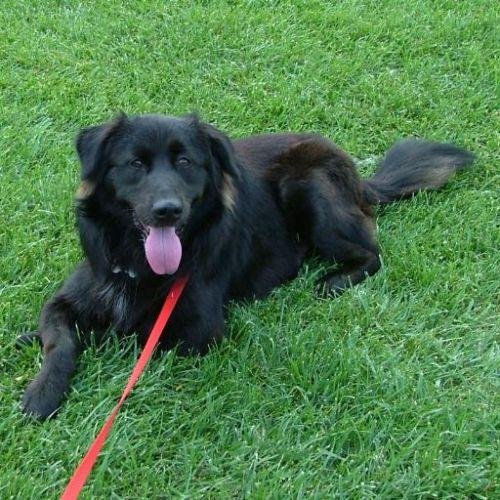

In [7]:
# Visualizando as imagens no Dataset
# As imagens Intituladas '0' são imagens de Gatos
# enquanto as imagens Intituladas '1' são de Cachorros

exemplo = dataset['train'][random.randint(0, len(dataset['train']))]
image = exemplo['image']
label = exemplo['labels']
print(label)
display(image)

In [8]:
# Filtra apenas os exemplos onde 'labels' é igual a 1 (cachorros)
dogs_dataset = dataset["train"].filter(lambda cachorros: cachorros["labels"] == 1)
print(f"Número de imagens de cachorros: {len(dogs_dataset)}")

Filter:   0%|          | 0/23410 [00:00<?, ? examples/s]

Número de imagens de cachorros: 11669


In [9]:
# Caminho local onde as imagens serão salvas
output_dir = os.path.join(DATASET_PATH, 'negative')
os.makedirs(output_dir, exist_ok=True)

# Configurações fáceis de alterar
NEGATIVE_IMAGES_TO_SAVE = 2000
CLEAR_OLD_NEGATIVE_IMAGES = True  # True = limpa a pasta antes de salvar novas imagens

# Limpa imagens antigas, se habilitado
if CLEAR_OLD_NEGATIVE_IMAGES:
    old_images = [
        f for f in os.listdir(output_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
    ]
    for old_file in old_images:
        os.remove(os.path.join(output_dir, old_file))
    print(f"🧹 {len(old_images)} imagens antigas removidas de: {output_dir}")

# Garante que não tente salvar mais imagens que o dataset possui
max_negative_images = min(NEGATIVE_IMAGES_TO_SAVE, len(dogs_dataset))

# Itera com barra de progresso (tqdm)
for example in tqdm(
    dogs_dataset.select(range(max_negative_images)),
    total=max_negative_images,
    desc='Salvando imagens negativas',
    unit='img'
    ):
    image = example["image"]  # Obtém a imagem no formato PIL
    unique_name = f"{uuid.uuid4()}.jpg"  # Gera um nome único para a imagem
    output_path = os.path.join(output_dir, unique_name)  # Define o caminho de salvamento
    image.save(output_path)  # Salva a imagem como arquivo JPG

print(f"✓ {max_negative_images} imagens negativas salvas em: {output_dir}")

🧹 0 imagens antigas removidas de: /content/negative


Salvando imagens negativas:   0%|          | 0/2000 [00:00<?, ?img/s]

✓ 2000 imagens negativas salvas em: /content/negative


In [10]:
def resize_and_rename_images(
    directory_path: str,
    target_size: tuple = (105, 105),
    output_format: str = 'jpg'
) -> None:
    """
    Redimensiona todas as imagens em um diretório e as renomeia com UUIDs únicos.

    Esta função processa imagens no diretório especificado, redimensionando-as
    para um tamanho padrão e atribuindo nomes únicos baseados em UUID para
    evitar conflitos de nomenclatura. Se a imagem já está no tamanho pré-processado,
    apenas a renomeia sem redimensionar.

    Args:
        directory_path (str): Caminho do diretório contendo as imagens
        target_size (tuple): Tamanho alvo (altura, largura) em pixels. Default: (105, 105)
        output_format (str): Formato de saída ('jpg', 'png', etc). Default: 'jpg'

    Returns:
        None

    Raises:
        FileNotFoundError: Se o diretório não existir

    Example:
        >>> resize_and_rename_images('./dataset/images')
    """
    # Formatos de imagem suportados
    SUPPORTED_FORMATS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

    # Validar diretório
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Diretório não encontrado: {directory_path}")

    # Filtrar apenas arquivos de imagem válidos para a barra de progresso
    image_files = [
        image_name for image_name in os.listdir(directory_path)
        if os.path.isfile(os.path.join(directory_path, image_name))
        and image_name.lower().endswith(SUPPORTED_FORMATS)
    ]

    if not image_files:
        print(f"⚠️  Nenhuma imagem válida encontrada em: {directory_path}")
        return

    # Contadores
    processed_count = 0
    skipped_count = 0
    error_count = 0

    print(f"\n{'='*70}")
    print(f"REDIMENSIONANDO E RENOMEANDO IMAGENS")
    print(f"{'='*70}")
    print(f"  Diretório: {directory_path}")
    print(f"  Tamanho alvo: {target_size}")
    print(f"  Total de imagens válidas: {len(image_files)}")
    print(f"{'='*70}\n")

    for image_name in tqdm(image_files, desc='Processando imagens', unit='img', dynamic_ncols=True):
        image_path = os.path.join(directory_path, image_name)

        try:
            # Carregar imagem
            with Image.open(image_path) as image:
                image_size = image.size  # (largura, altura)

                # Verificar se a imagem já está no tamanho pré-processado
                if image_size == target_size:
                    # Apenas renomear sem redimensionar
                    unique_name = f"{uuid.uuid4()}.{output_format}"
                    new_image_path = os.path.join(directory_path, unique_name)

                    # Salvar sem redimensionar
                    image.save(new_image_path, quality=95)
                    os.remove(image_path)
                    skipped_count += 1
                else:
                    # Redimensionar imagem com qualidade
                    resized_image = image.resize(target_size, Image.Resampling.LANCZOS)

                    # Gerar nome único
                    unique_name = f"{uuid.uuid4()}.{output_format}"
                    new_image_path = os.path.join(directory_path, unique_name)

                    # Salvar com qualidade alta
                    resized_image.save(new_image_path, quality=95)
                    os.remove(image_path)
                    processed_count += 1

        except Exception as e:
            error_count += 1
            print(f"  ⚠️  Erro: {image_name} - {e}")

    # Exibir resumo
    print(f"\n{'='*70}")
    print(f"✓ PROCESSAMENTO CONCLUÍDO")
    print(f"{'='*70}")
    print(f"  Imagens redimensionadas: {processed_count}")
    print(f"  Imagens puladas (já no tamanho {target_size}): {skipped_count}")
    print(f"  Erros encontrados: {error_count}")
    print(f"  Total processado: {processed_count + skipped_count}")
    print(f"{'='*70}\n")

In [11]:
resize_and_rename_images(NEG_PATH)


REDIMENSIONANDO E RENOMEANDO IMAGENS
  Diretório: /content/negative
  Tamanho alvo: (105, 105)
  Total de imagens válidas: 2000



Processando imagens:   0%|          | 0/2000 [00:00<?, ?img/s]


✓ PROCESSAMENTO CONCLUÍDO
  Imagens redimensionadas: 2000
  Imagens puladas (já no tamanho (105, 105)): 0
  Erros encontrados: 0
  Total processado: 2000



## 2.3 Importando Fotos de Cachorros Individuais - Web Scrapping

Importamos as fotos um web scrapping usando selenium na página: https://www.flickr.com/groups/doggystyle/pool/101596138@N05/

In [ ]:
"""
Scraping manual do grupo Flickr 'dogs' usando Selenium.
Navega página por página, clica em cada foto e baixa a versão grande.

Requisitos:
    pip install selenium

Uso:
    python baixar_flickr_selenium.py

Observações:
    - Precisa do Chrome instalado (ou troque por Firefox)
    - O ChromeDriver é gerenciado automaticamente pelo Selenium 4+
    - As imagens são salvas em ./flickr_dogs/
"""

# ── Configurações ──────────────────────────────────────────────────────────────
BASE_URL    = "https://www.flickr.com/groups/doggystyle/pool/101596138@N05/page{:02d}"
TOTAL_PAGES = 11
OUTPUT_DIR  = "./flickr_dogs"
DELAY_SHORT = 1.5   # segundos entre ações rápidas
DELAY_LONG  = 3.0   # segundos após navegação/clique em foto
TIMEOUT     = 15    # segundos para WebDriverWait
# ──────────────────────────────────────────────────────────────────────────────


def build_driver(headless: bool = False) -> webdriver.Chrome:
    """Cria e retorna o driver Chrome."""
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")
    opts.add_argument("--disable-notifications")
    opts.add_argument("--disable-popup-blocking")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--lang=pt-BR")
    opts.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
    driver = webdriver.Chrome(options=opts)
    driver.set_window_size(1400, 900)
    return driver


def close_cookie_banner(driver: webdriver.Chrome) -> None:
    """Fecha banners de cookies/GDPR se existirem."""
    selectors = [
        "button[data-testid='close']",
        "button.onetrust-close-btn-handler",
        "button#onetrust-accept-btn-handler",
        "button[aria-label='Close']",
        ".gdpr-cookie-notice button",
    ]
    for sel in selectors:
        try:
            btn = driver.find_element(By.CSS_SELECTOR, sel)
            btn.click()
            time.sleep(0.5)
            return
        except Exception:
            continue


def scroll_page_to_load(driver: webdriver.Chrome, scrolls: int = 5) -> None:
    """Faz scroll suave para garantir que todos os thumbnails carreguem (lazy load)."""
    for _ in range(scrolls):
        driver.execute_script("window.scrollBy(0, 600);")
        time.sleep(0.6)
    # Volta ao topo para facilitar a coleta dos links
    driver.execute_script("window.scrollTo(0, 0);")
    time.sleep(0.5)


def get_photo_links_from_pool_page(driver: webdriver.Chrome, pool_url: str) -> list[str]:
    """
    Abre uma página do pool e retorna todos os links de fotos individuais.
    Aguarda os thumbnails carregarem via AJAX antes de coletar.
    """
    driver.get(pool_url)
    time.sleep(DELAY_LONG)
    close_cookie_banner(driver)

    # Aguarda os thumbnails aparecerem
    try:
        WebDriverWait(driver, TIMEOUT).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "a.overlay"))
        )
    except TimeoutException:
        print("  [AVISO] Timeout aguardando thumbnails — tentando mesmo assim...")

    scroll_page_to_load(driver, scrolls=6)

    # Coleta todos os hrefs de fotos individuais
    links = set()
    # Seletor principal: links com classe 'overlay' sobre cada thumbnail
    for a in driver.find_elements(By.CSS_SELECTOR, "a.overlay[href*='/photos/']"):
        href = a.get_attribute("href") or ""
        if re.search(r"/photos/[^/]+/\d+", href):
            # Garante URL absoluta
            if href.startswith("/"):
                href = "https://www.flickr.com" + href
            links.add(href.split("?")[0])  # Remove query string

    # Fallback: qualquer <a> cujo href seja página de foto
    if not links:
        for a in driver.find_elements(By.CSS_SELECTOR, "a[href*='/photos/']"):
            href = a.get_attribute("href") or ""
            if re.search(r"/photos/[^/]+/\d+/?$", href):
                if href.startswith("/"):
                    href = "https://www.flickr.com" + href
                links.add(href.split("?")[0])

    return sorted(links)


def extract_large_image_url(driver: webdriver.Chrome, photo_url: str) -> str | None:
    """
    Abre a página individual da foto e extrai a URL da imagem grande.
    Estratégias em ordem de prioridade:
      1. Botão "Baixar" → pega a URL do maior tamanho disponível
      2. Tag <img> com class 'main-photo'
      3. Meta og:image
      4. Regex no source da página
    """
    driver.get(photo_url)
    time.sleep(DELAY_LONG)

    # ── Estratégia 1: URL da imagem principal visível ─────────────────────────
    # O Flickr carrega a foto grande em uma <img> com classe específica
    for css in [
        "img.main-photo",
        "div.photo-card-content img",
        "div.photo-content img",
        "img[class*='photo']",
        "div.zoom-photo-container img",
    ]:
        try:
            el = WebDriverWait(driver, 8).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, css))
            )
            src = el.get_attribute("src") or ""
            if src and "staticflickr" in src:
                # Converte para versão grande (_b = 1024px)
                src = re.sub(r"_(m|s|t|q|n|z|c)\.", "_b.", src)
                return src
        except (TimeoutException, NoSuchElementException):
            continue

    # ── Estratégia 2: Meta og:image ───────────────────────────────────────────
    try:
        el = driver.find_element(By.CSS_SELECTOR, "meta[property='og:image']")
        content = el.get_attribute("content") or ""
        if content and "staticflickr" in content:
            return content
    except NoSuchElementException:
        pass

    # ── Estratégia 3: Regex no HTML da página ────────────────────────────────
    page_source = driver.page_source
    # Procura URLs de imagens grandes: sufixo _b, _o, _z, _c (ordenado por tamanho)
    for suffix in ["_b", "_o", "_z", "_c"]:
        pattern = r'https://live\.staticflickr\.com/[^\s"\'\\]+' + re.escape(suffix) + r'\.jpg'
        matches = re.findall(pattern, page_source)
        if matches:
            return matches[0]

    # ── Estratégia 4: Botão de download ──────────────────────────────────────
    try:
        btn = driver.find_element(By.CSS_SELECTOR,
            "a[data-track='photo_download'], a.download-link, a[href*='download']")
        href = btn.get_attribute("href") or ""
        if href and "flickr" in href:
            return href
    except NoSuchElementException:
        pass

    return None


def safe_download(img_url: str, dest_path: str) -> bool:
    """Baixa a imagem com User-Agent adequado."""
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        )
    }
    try:
        req = urllib.request.Request(img_url, headers=headers)
        with urllib.request.urlopen(req, timeout=30) as response:
            with open(dest_path, "wb") as f:
                f.write(response.read())
        return True
    except (urllib.error.URLError, OSError) as e:
        print(f"    [ERRO] Download falhou: {e}")
        return False


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Muda para headless=True se não quiser ver o navegador
    driver = build_driver(headless=False)
    wait = WebDriverWait(driver, TIMEOUT)

    total_saved  = 0
    total_failed = 0
    total_skip   = 0

    try:
        for page_num in range(1, TOTAL_PAGES + 1):
            pool_url = BASE_URL.format(page_num)
            print(f"\n{'='*65}")
            print(f"  PÁGINA {page_num}/{TOTAL_PAGES} — {pool_url}")
            print(f"{'='*65}")

            photo_links = get_photo_links_from_pool_page(driver, pool_url)
            print(f"  {len(photo_links)} foto(s) encontrada(s) nesta página.\n")

            if not photo_links:
                print("  Nenhum link coletado — pulando página.")
                continue

            for idx, photo_url in enumerate(photo_links, start=1):
                # ID da foto para nomear o arquivo
                m = re.search(r"/photos/[^/]+/(\d+)", photo_url)
                photo_id = m.group(1) if m else f"{page_num}_{idx:03d}"
                filename  = f"p{page_num:02d}_{photo_id}.jpg"
                dest_path = os.path.join(OUTPUT_DIR, filename)

                if os.path.exists(dest_path):
                    print(f"  [{idx:>3}/{len(photo_links)}] ✓ Já existe: {filename}")
                    total_skip += 1
                    continue

                print(f"  [{idx:>3}/{len(photo_links)}] Abrindo foto {photo_id}...")

                img_url = extract_large_image_url(driver, photo_url)

                if not img_url:
                    print(f"           ✗ URL da imagem não encontrada.")
                    total_failed += 1
                    time.sleep(DELAY_SHORT)
                    continue

                print(f"           ↓ {img_url[:80]}...")
                ok = safe_download(img_url, dest_path)

                if ok:
                    size_kb = os.path.getsize(dest_path) // 1024
                    print(f"           ✔ Salvo: {filename} ({size_kb} KB)")
                    total_saved += 1
                else:
                    total_failed += 1

                time.sleep(DELAY_SHORT)

            print(f"\n  Página {page_num} concluída. Aguardando {DELAY_LONG}s...")
            time.sleep(DELAY_LONG)

    except KeyboardInterrupt:
        print("\n\n[INTERROMPIDO pelo usuário]")

    finally:
        driver.quit()
        print(f"\n{'='*65}")
        print(f"  RESULTADO FINAL")
        print(f"  Salvas:     {total_saved}")
        print(f"  Ignoradas:  {total_skip}  (já existiam)")
        print(f"  Falhas:     {total_failed}")
        print(f"  Pasta:      {os.path.abspath(OUTPUT_DIR)}")
        print(f"{'='*65}")


if __name__ == "__main__":
    main()

In [ ]:
# Modificando o nome e o tamanho da imagem para 105x105 px
output_path = POS_PATH

## 2.4 Movendo metade das fotos positivas para âncora (Não Ideal)

In [ ]:
# Diretório original (contém todas as imagens)
source_dir = POS_PATH

# Diretório de destino (onde metade das imagens será movida)
destination_dir = ANC_PATH

In [ ]:
def move_half(source_dir, destination_dir):
  # Verifica e deleta imagens existentes no diretório de destino
  deleted_count = 0
  existing_images = [f for f in os.listdir(destination_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

  if existing_images:
    print(f"Encontradas {len(existing_images)} imagens existentes em {destination_dir}. Deletando...")
    for image_name in existing_images:
      try:
        image_path = os.path.join(destination_dir, image_name)
        os.remove(image_path)
        deleted_count += 1
      except Exception as e:
        print(f"Erro ao deletar {image_name}: {e}")
    print(f"✓ {deleted_count} imagens deletadas com sucesso.")

  # Lista todas as imagens no diretório original
  image_files = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

  # Embaralha a lista para seleção aleatória
  random.shuffle(image_files)

  # Calcula a metade do número total de imagens
  half_size = len(image_files) // 2

  # Seleciona metade das imagens para mover
  images_to_move = image_files[:half_size]

  # Move as imagens selecionadas
  moved_count = 0
  error_count = 0
  for image_name in images_to_move:
      source_path = os.path.join(source_dir, image_name)  # Caminho de origem
      destination_path = os.path.join(destination_dir, image_name)  # Caminho de destino
      try:
        shutil.move(source_path, destination_path)  # Move a imagem
        moved_count += 1
      except Exception as e:
        print(f"Erro ao mover {image_name}: {e}")
        error_count += 1

  print(f"\n--- Resumo da Operação move_half ---")
  if deleted_count > 0:
    print(f"✓ Deletadas: {deleted_count} imagens do diretório {destination_dir}")
  print(f"✓ Movidas: {moved_count} imagens para {destination_dir}")
  if error_count > 0:
    print(f"✗ Erros: {error_count} imagens não puderam ser movidas")
  print(f"Total de imagens agora em {destination_dir}: {moved_count}")

In [ ]:
move_half(source_dir, destination_dir)

# **3 - Pré-Processamento de Imagens**

## 3.1 Redimensionamento de Imagens

In [ ]:
resize_and_rename_images(NEG_PATH)
resize_and_rename_images(POS_PATH)
resize_and_rename_images(ANC_PATH)


REDIMENSIONANDO E RENOMEANDO IMAGENS
  Diretório: /content/negative
  Tamanho alvo: (105, 105)
  Total de imagens válidas: 2000



Processando imagens:   0%|          | 0/2000 [00:00<?, ?img/s]


✓ PROCESSAMENTO CONCLUÍDO
  Imagens redimensionadas: 0
  Imagens puladas (já no tamanho (105, 105)): 2000
  Erros encontrados: 0
  Total processado: 2000


REDIMENSIONANDO E RENOMEANDO IMAGENS
  Diretório: /content/positive
  Tamanho alvo: (105, 105)
  Total de imagens válidas: 127



Processando imagens:   0%|          | 0/127 [00:00<?, ?img/s]


✓ PROCESSAMENTO CONCLUÍDO
  Imagens redimensionadas: 0
  Imagens puladas (já no tamanho (105, 105)): 127
  Erros encontrados: 0
  Total processado: 127


REDIMENSIONANDO E RENOMEANDO IMAGENS
  Diretório: /content/anchor
  Tamanho alvo: (105, 105)
  Total de imagens válidas: 131



Processando imagens:   0%|          | 0/131 [00:00<?, ?img/s]


✓ PROCESSAMENTO CONCLUÍDO
  Imagens redimensionadas: 0
  Imagens puladas (já no tamanho (105, 105)): 131
  Erros encontrados: 0
  Total processado: 131



## 3.2 - Augmentação de Imagens

In [12]:
def augment_image(input_dir, output_dir):
    """
    Augmenta imagens com transformações diversificadas incluindo cor.

    Se já existirem imagens augmentadas no diretório de saída, elas serão removidas
    antes de processar as novas augmentações.

    Transformações aplicadas:
    - Flip horizontal aleatório
    - Ajuste de brilho (±10%)
    - Ajuste de contraste (0.8 a 1.2x)
    - Rotação aleatória (0°, 90°, 180°, 270°)
    - Ajuste de saturação de cor (0.7 a 1.3x) - Seguro para reconhecimento
    - Ajuste de tonalidade (hue shift) de até ±0.1 - Seguro para reconhecimento

    Args:
        input_dir (str): Diretório contendo imagens originais
        output_dir (str): Diretório onde salvar imagens augmentadas
    """

    # ========== LIMPEZA DE IMAGENS AUGMENTADAS EXISTENTES ==========
    print(f"\n{'='*70}")
    print("LIMPEZA DE IMAGENS AUGMENTADAS EXISTENTES")
    print(f"{'='*70}\n")

    augmented_images = [f for f in os.listdir(output_dir) if f.startswith('augmented_') and f.endswith('.jpg')]

    if augmented_images:
        print(f"  Encontradas {len(augmented_images)} imagens augmentadas existentes")
        print(f"  Removendo...")

        deleted_count = 0
        for img_file in augmented_images:
            try:
                img_path = os.path.join(output_dir, img_file)
                os.remove(img_path)
                deleted_count += 1
            except Exception as e:
                print(f"  ⚠️  Erro ao deletar {img_file}: {e}")

        print(f"  ✓ {deleted_count} imagens removidas com sucesso!")
    else:
        print(f"  Nenhuma imagem augmentada encontrada.")

    # ========== AUGMENTAÇÃO DE NOVAS IMAGENS ==========
    print(f"\n{'='*70}")
    print("INICIANDO AUGMENTAÇÃO DE IMAGENS")
    print(f"{'='*70}\n")

    image_paths = glob(os.path.join(input_dir, '*.jpg'))

    if not image_paths:
        print(f"  ⚠️  Nenhuma imagem encontrada em: {input_dir}")
        return

    processed_count = 0
    error_count = 0

    for i, img_path in enumerate(image_paths):
        try:
            # Carrega a imagem como PIL Image e converte para array numpy
            pil_image = Image.open(img_path)

            # Converter para RGB se necessário (remover canal alfa, etc)
            if pil_image.mode != 'RGB':
                pil_image = pil_image.convert('RGB')

            # Converter PIL Image para numpy array (uint8, valores 0-255)
            image_array = np.array(pil_image, dtype=np.uint8)

            # Converter para tensor float32 (0-1) para operações TensorFlow
            image = tf.convert_to_tensor(image_array, dtype=tf.float32)
            image = image / 255.0  # Normalizar para 0-1

            # ========== TRANSFORMAÇÕES GEOMÉTRICAS ==========
            # Flip horizontal aleatório (50% de chance)
            if random.random() > 0.5:
                image = tf.image.flip_left_right(image)

            # Rotação aleatória (0°, 90°, 180°, 270°)
            random_rotation = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
            image = tf.image.rot90(image, k=random_rotation)

            # ========== TRANSFORMAÇÕES DE BRILHO E CONTRASTE ==========
            # Ajuste de brilho (±10%)
            image = tf.image.random_brightness(image, max_delta=0.1)

            # Ajuste de contraste (0.8 a 1.2x)
            image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

            # ========== TRANSFORMAÇÕES DE COR (SEGURAS PARA RECONHECIMENTO) ==========
            # Ajuste de saturação (0.7 a 1.3x)
            saturation_factor = tf.random.uniform(shape=[], minval=0.7, maxval=1.3, dtype=tf.float32)
            image = tf.image.adjust_saturation(image, saturation_factor)

            # Ajuste de tonalidade/hue (±0.1)
            hue_delta = tf.random.uniform(shape=[], minval=-0.1, maxval=0.1, dtype=tf.float32)
            image = tf.image.adjust_hue(image, hue_delta)

            # ========== PÓS-PROCESSAMENTO ==========
            # Clipping de valores para garantir interval [0, 1]
            image = tf.clip_by_value(image, 0.0, 1.0)

            # Converter para numpy array e depois para uint8 (0-255)
            image_numpy = image.numpy()
            image_uint8 = (image_numpy * 255).astype(np.uint8)

            # Converter de volta para PIL Image
            image_pil = Image.fromarray(image_uint8, mode='RGB')

            # Gera um nome de arquivo único com UUID
            unique_filename = f"augmented_{uuid.uuid4().hex}.jpg"
            output_path = os.path.join(output_dir, unique_filename)

            # Salva a imagem aumentada no diretório de saída
            image_pil.save(output_path, quality=95)

            processed_count += 1

            # Exibir progresso
            if (i + 1) % 10 == 0 or (i + 1) == len(image_paths):
                print(f"  {i + 1}/{len(image_paths)} imagens processadas...")

        except Exception as e:
            error_count += 1
            print(f"  ⚠️  Erro ao processar {os.path.basename(img_path)}: {e}")

    # ========== RESUMO DA AUGMENTAÇÃO ==========
    print(f"\n{'='*70}")
    print("✓ AUGMENTAÇÃO CONCLUÍDA")
    print(f"{'='*70}")
    print(f"  Imagens processadas: {processed_count}")
    print(f"  Erros encontrados: {error_count}")
    print(f"  Localização: {output_dir}")
    print(f"{'='*70}\n")

In [13]:
augment_image(POS_PATH, POS_PATH)
augment_image(ANC_PATH, ANC_PATH)


LIMPEZA DE IMAGENS AUGMENTADAS EXISTENTES

  Nenhuma imagem augmentada encontrada.

INICIANDO AUGMENTAÇÃO DE IMAGENS

  10/127 imagens processadas...
  20/127 imagens processadas...
  30/127 imagens processadas...
  40/127 imagens processadas...
  50/127 imagens processadas...
  60/127 imagens processadas...
  70/127 imagens processadas...
  80/127 imagens processadas...
  90/127 imagens processadas...
  100/127 imagens processadas...
  110/127 imagens processadas...
  120/127 imagens processadas...
  127/127 imagens processadas...

✓ AUGMENTAÇÃO CONCLUÍDA
  Imagens processadas: 127
  Erros encontrados: 0
  Localização: /content/positive


LIMPEZA DE IMAGENS AUGMENTADAS EXISTENTES

  Nenhuma imagem augmentada encontrada.

INICIANDO AUGMENTAÇÃO DE IMAGENS

  10/131 imagens processadas...
  20/131 imagens processadas...
  30/131 imagens processadas...
  40/131 imagens processadas...
  50/131 imagens processadas...
  60/131 imagens processadas...
  70/131 imagens processadas...
  80/131 

## 3.3 Tratamento de Imagens Não RGB

In [14]:
# ========== Excluir imagens inválidas e não-RGB antes do pipeline ==========
def remove_non_rgb_images(*directories):
  """Remove fisicamente do disco arquivos que não são imagens RGB válidas."""
  total_removed = 0
  for directory in directories:
    for img_file in os.listdir(directory):
      img_path = os.path.join(directory, img_file)

      # Ignorar subdiretórios
      if os.path.isdir(img_path):
        continue

      # Remover arquivos que não são imagens (sem extensão válida)
      if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
        print(f"  ⚠️  Removido (não é imagem): {img_path}")
        os.remove(img_path)
        total_removed += 1
        continue

      try:
        img = Image.open(img_path)
        img.verify()
        # Reabrir após verify (verify invalida o objeto)
        img = Image.open(img_path)
        if img.mode != 'RGB':
          print(f"  ⚠️  Excluída ({img.mode}): {img_path}")
          img.close()
          os.remove(img_path)
          total_removed += 1
        else:
          img.close()
      except Exception as e:
        print(f"  ⚠️  Corrompida: {img_path} ({e}) - removendo...")
        os.remove(img_path)
        total_removed += 1
  print(f"✓ {total_removed} arquivo(s) inválido(s) removido(s)")

In [15]:

# Executar limpeza nos 3 diretórios
remove_non_rgb_images(ANC_PATH, POS_PATH, NEG_PATH)

✓ 0 arquivo(s) inválido(s) removido(s)


## 3.4 Carregando Diretório de Imagens

In [16]:
# Verificando o número de imagens em cada diretório após a augmentação
def count_images_in_directory(directory_path):
    """Conta o número de imagens em um diretório específico."""
    image_files = [f for f in os.listdir(directory_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    return len(image_files)

# Imprimindo o número de imagens em cada diretório
print(f"Imagens em anchor: {count_images_in_directory(ANC_PATH)}")
print(f"Imagens em positive: {count_images_in_directory(POS_PATH)}")
print(f"Imagens em negative: {count_images_in_directory(NEG_PATH)}")

Imagens em anchor: 262
Imagens em positive: 254
Imagens em negative: 2000


In [17]:
# Definindo o caminho para cada imagem dos diretórios específicos para cada imagem
anchor = tf.data.Dataset.list_files(ANC_PATH+'/*.jpg')
positive = tf.data.Dataset.list_files(POS_PATH+'/*.jpg')
negative = tf.data.Dataset.list_files(NEG_PATH+'/*.jpg')
len(negative)

2000

In [18]:
dir_test = anchor.as_numpy_iterator()

In [19]:
print(dir_test.next())

b'/content/anchor/4335cea0-9bf0-461b-83fa-c7d2672d64aa.jpg'


## 3.5 Estruturando o Dataset

O que queremos é criar algo que contenha a informação de que, em uma comparação entre duas imagens, elas são ou não compatíveis, e qual o caminho de acesso para essas imagens. Iremos estruturar da forma: **(caminho_ancora, caminho_pos_ou_neg, compatibilidade)**.

Especificamente, comparações entre ancoras e positivos terão compatibilidade, ou seja, carregará o valor 1, caso for comparado com imagens negativas, valor 0.

In [20]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))

# Para o dataset de negativos, repetimos o dataset 'anchor' e o limitamos ao tamanho do dataset 'negative'
repeated_anchor_for_negatives = anchor.repeat().take(len(negative))
negatives = tf.data.Dataset.zip((repeated_anchor_for_negatives, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(negative)))))

data = positives.concatenate(negatives)

In [22]:
samples = data.as_numpy_iterator()

In [23]:
samples.next()

(b'/content/anchor/augmented_8a10b42672be4f2389c1fcf8bb7d1c97.jpg',
 b'/content/positive/dfc989b5-33a1-4200-8e20-18ce2442ff49.jpg',
 np.float32(1.0))

## 3.6 Tratando imagens para treinamento na Rede Neural

In [24]:
def preprocess(file_path):
  # Lê a imagem
  byte_img = tf.io.read_file(file_path)
  # Carrega a imagem como JPEG forçando 3 canais (RGB) como segurança
  img = tf.io.decode_jpeg(byte_img, channels=3)
  # Modifica o tamanho da imagem em 105x105x3(RGB) - Tamanho ideal para treinamento
  img = tf.image.resize(img, (105,105))
  # Escala as informações da imagem para estarem entre 0 e 1
  img = img / 255.0
  return img

In [25]:
# Realiza o pré-processamento de dados dentro do Dataset estruturado
def preprocess_twin(input_img, validation_img, label):
  return(preprocess(input_img), preprocess(validation_img), label)

In [26]:
# Dataloader Pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [27]:
samples = data.as_numpy_iterator()

In [28]:
samples = samples.next()
samples

(array([[[0.4627451 , 0.62352943, 0.70980394],
         [0.40784314, 0.57254905, 0.65882355],
         [0.34117648, 0.5137255 , 0.6117647 ],
         ...,
         [0.2627451 , 0.15294118, 0.13725491],
         [0.25490198, 0.14509805, 0.12941177],
         [0.2509804 , 0.15294118, 0.1254902 ]],
 
        [[0.22352941, 0.40392157, 0.49803922],
         [0.25490198, 0.44313726, 0.53333336],
         [0.26666668, 0.4627451 , 0.5686275 ],
         ...,
         [0.28627452, 0.1764706 , 0.16078432],
         [0.25490198, 0.15686275, 0.13725491],
         [0.2627451 , 0.16470589, 0.13725491]],
 
        [[0.25882354, 0.49411765, 0.6039216 ],
         [0.23529412, 0.47058824, 0.5803922 ],
         [0.24313726, 0.48235294, 0.6039216 ],
         ...,
         [0.27450982, 0.1764706 , 0.15686275],
         [0.2509804 , 0.16078432, 0.13725491],
         [0.27450982, 0.18431373, 0.15294118]],
 
        ...,
 
        [[0.14509805, 0.14509805, 0.11372549],
         [0.14901961, 0.14901961, 0.11764

## 3.7 - Amostra de Imagens + Label

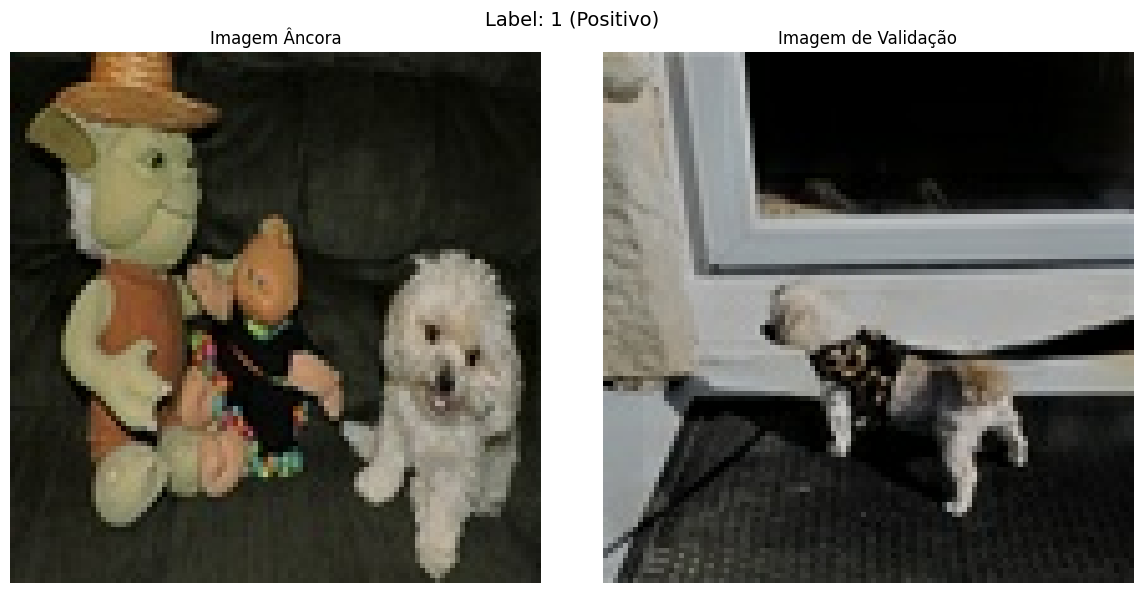

In [29]:
# Buscar uma amostra do dataset processado e visualizar
samples = data.as_numpy_iterator()
sample = next(samples)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sample[0])
axes[0].set_title('Imagem Âncora')
axes[0].axis('off')

axes[1].imshow(sample[1])
axes[1].set_title('Imagem de Validação')
axes[1].axis('off')

fig.suptitle(f'Label: {sample[2]:.0f} ({"Positivo" if sample[2] > 0.5 else "Negativo"})', fontsize=14)
plt.tight_layout()
plt.show()

## 3.8 Realizando a Divisão Treino/Teste

In [30]:
# Criando as repartições de Treino e Teste
# Calcular número total de elementos
total_elements = len(positives) + len(negatives)  # Usar o tamanho original dos datasets
print(f"Total de elementos no dataset: {total_elements}")

# 70% para treino, 30% para teste
train_size = round(total_elements * 0.7)
test_size = round(total_elements * 0.3)

print(f"  Treino: {train_size} ({train_size/total_elements*100:.1f}%)")
print(f"  Teste: {test_size} ({test_size/total_elements*100:.1f}%)")

# BATCH_SIZE
BATCH_SIZE = 16

# Dividir em train e test
train_data = data.take(train_size)
test_data = data.skip(train_size)

# Aplicar batch e prefetch
train_data = train_data.batch(BATCH_SIZE)
train_data = train_data.prefetch(tf.data.AUTOTUNE)

test_data = test_data.batch(BATCH_SIZE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

print(f"\n✓ Datasets criados com sucesso!")
print(f"  Train batches: {len(list(train_data.as_numpy_iterator()))}")
print(f"  Test batches: {len(list(test_data.as_numpy_iterator()))}")

Total de elementos no dataset: 2254
  Treino: 1578 (70.0%)
  Teste: 676 (30.0%)

✓ Datasets criados com sucesso!
  Train batches: 99
  Test batches: 43


In [31]:
# Visualizar estrutura dos dados de treino
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 105, 105, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 105, 105, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [32]:
# Visualizar estrutura dos dados de teste
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 105, 105, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 105, 105, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

# **4 - Construção do Modelo**

## 4.1 Camada de Embedding

In [33]:
def build_embedding_network(
    input_shape: tuple = (105, 105, 3),
    num_units: int = 4096
) -> Model:
    """
    Constrói uma rede de embedding para a arquitetura Siamesa.

    A rede usa 4 blocos convolucionais progressivos com pooling e dropout
    para extrair features discriminativas das imagens de entrada.

    Arquitetura:
    - Bloco 1: Conv2D(64, 10×10) → MaxPooling → Dropout(0.3)
    - Bloco 2: Conv2D(128, 7×7) → MaxPooling → Dropout(0.3)
    - Bloco 3: Conv2D(128, 4×4) → MaxPooling → Dropout(0.3)
    - Bloco 4: Conv2D(256, 4×4) → Flatten → Dense(4096, sigmoid)

    Args:
        input_shape (tuple): Forma da entrada (altura, largura, canais). Default: (105, 105, 3)
        num_units (int): Número de unidades na camada de saída. Default: 4096

    Returns:
        Model: Modelo Keras compilado de embedding

    Raises:
        ValueError: Se input_shape não tiver 3 canais (RGB)

    Example:
        >>> embedding_model = build_embedding_network()
        >>> embedding_model.summary()
    """
    # Validar entrada
    if len(input_shape) != 3 or input_shape[2] != 3:
        raise ValueError(f"input_shape deve ser (altura, largura, 3), recebido {input_shape}")

    # Camada de entrada
    input_layer = Input(shape=input_shape, name='input_image')

    # ========== Bloco 1 - Features de Baixo Nível ==========
    conv1 = Conv2D(
        filters=64,
        kernel_size=(10, 10),
        activation='relu',
        padding='same',
        name='conv1'
    )(input_layer)
    pool1 = MaxPooling2D(
        pool_size=(2, 2),
        padding='same',
        name='pool1'
    )(conv1)
    drop1 = Dropout(rate=0.3, name='dropout1')(pool1)

    # ========== Bloco 2 - Features de Nível Médio ==========
    conv2 = Conv2D(
        filters=128,
        kernel_size=(7, 7),
        activation='relu',
        padding='same',
        name='conv2'
    )(drop1)
    pool2 = MaxPooling2D(
        pool_size=(2, 2),
        padding='same',
        name='pool2'
    )(conv2)
    drop2 = Dropout(rate=0.3, name='dropout2')(pool2)

    # ========== Bloco 3 - Features de Nível Alto ==========
    conv3 = Conv2D(
        filters=128,
        kernel_size=(4, 4),
        activation='relu',
        padding='same',
        name='conv3'
    )(drop2)
    pool3 = MaxPooling2D(
        pool_size=(2, 2),
        padding='same',
        name='pool3'
    )(conv3)
    drop3 = Dropout(rate=0.3, name='dropout3')(pool3)

    # ========== Bloco 4 - Embedding Final ==========
    conv4 = Conv2D(
        filters=256,
        kernel_size=(4, 4),
        activation='relu',
        padding='same',
        name='conv4'
    )(drop3)

    # Achatamento e camada densa de embedding
    flatten = Flatten(name='flatten')(conv4)
    embedding_output = Dense(
        units=num_units,
        activation='sigmoid',
        name='embedding'
    )(flatten)

    # Criar e retornar modelo
    embedding_model = Model(
        inputs=input_layer,
        outputs=embedding_output,
        name='embedding_network'
    )

    return embedding_model


# Construir modelo de embedding
embedding = build_embedding_network()

print("\n" + "="*70)
print("MODELO DE EMBEDDING CRIADO")
print("="*70)
embedding.summary()
print("="*70 + "\n")


MODELO DE EMBEDDING CRIADO


Model: "embedding_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 105, 105, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 105, 105, 64)   │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 53, 53, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 27, 27, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 14, 14, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 4096)           │   205,524,992 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,732,608 (788.62 MB)

 Trainable params: 206,732,608 (788.62 MB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Camada de Distância

In [34]:
class L1Distance(Layer):
    """
    Camada customizada que calcula a distância L1 entre dois embeddings.

    A distância L1 (Manhattan) é usada para comparar embeddings na rede Siamesa.
    Quanto menor a distância, mais similares são os embeddings.

    Fórmula: d = sum(|a_i - b_i|) para todos os elementos i

    Esta camada é fundamental para a rede Siamesa, permitindo comparar
    dois embeddings e gerar uma medida de similaridade.

    Example:
        >>> distance_layer = L1Distance()
        >>> distance = distance_layer([embedding1, embedding2])
        >>> # Resultado: tensor com distâncias L1
    """

    def __init__(self, **kwargs):
        """
        Inicializa a camada L1Distance.

        Args:
            **kwargs: Argumentos adicionais para a classe Layer pai
        """
        super().__init__(**kwargs)
        self.name = 'L1Distance'

    def call(self, inputs: list) -> tf.Tensor:
        """
        Calcula a distância L1 entre dois embeddings.

        Args:
            inputs (list): Lista com dois tensores [embedding1, embedding2]

        Returns:
            tf.Tensor: Tensor com as distâncias L1 (valor absoluto das diferenças)

        Raises:
            ValueError: Se inputs não contiver exatamente 2 elementos
        """
        if len(inputs) != 2:
            raise ValueError(f"L1Distance espera 2 inputs, recebeu {len(inputs)}")

        input_embedding, validation_embedding = inputs

        # Calcular valor absoluto das diferenças (L1 distance)
        return tf.math.abs(input_embedding - validation_embedding)

    def get_config(self) -> dict:
        """
        Retorna a configuração da camada para serialização e carregamento posterior.

        Returns:
            dict: Configuração da camada
        """
        config = super().get_config()
        return config


# Criar instância da camada
l1_distance = L1Distance()

print("✓ Camada L1Distance criada com sucesso!")

✓ Camada L1Distance criada com sucesso!


## 4.3 Cria o Modelo Siamês

In [35]:
def build_siamese_network(
    embedding_model: Model,
    distance_layer: Layer,
    input_shape: tuple = (105, 105, 3)
) -> Model:
    """
    Constrói a rede neural Siamesa completa para comparação de imagens.

    A rede Siamesa consiste em:
    1. Duas branches com arquitetura idêntica (embedding_model)
    2. Uma camada de distância L1 que compara os embeddings
    3. Uma camada de classificação que prediz similaridade

    Args:
        embedding_model (Model): Modelo de embedding pré-construído
        distance_layer (Layer): Camada de cálculo de distância (L1Distance)
        input_shape (tuple): Forma das imagens de entrada. Default: (100, 100, 3)

    Returns:
        Model: Modelo Siamesa compilado e pronto para treinamento

    Example:
        >>> siamese_net = build_siamese_network(embedding, l1_distance)
        >>> siamese_net.summary()
    """
    # Entradas - Imagens para comparação
    input_img = Input(
        name='input_img',
        shape=input_shape
    )
    validation_img = Input(
        name='validation_img',
        shape=input_shape
    )

    # Gerar embeddings usando os dois branches (compartilham pesos)
    embedding_input = embedding_model(input_img)
    embedding_validation = embedding_model(validation_img)

    # Camada de distância L1
    distances = distance_layer([embedding_input, embedding_validation])

    # Camada de classificação - predizer similaridade
    classifier = Dense(
        units=1,
        activation='sigmoid',
        name='similarity'
    )(distances)

    # Criar modelo Siamesa
    siamese_model = Model(
        inputs=[input_img, validation_img],
        outputs=classifier,
        name='SiameseNetwork'
    )

    return siamese_model

In [36]:
# Construir rede Siamesa
siamese_network = build_siamese_network(
    embedding_model=embedding,
    distance_layer=l1_distance
)

print("\n" + "="*70)
print("REDE SIAMESA CONSTRUÍDA")
print("="*70)
siamese_network.summary()
print("="*70 + "\n")


REDE SIAMESA CONSTRUÍDA


Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_network   │ (None, 4096)      │ 206,732,6… │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ L1Distance          │ (None, 4096)      │          0 │ embedding_networ… │
│ (L1Distance)        │                   │            │ embedding_networ… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similarity (Dense)  │ (None, 1)         │      4,097 │ L1Distance[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 206,736,705 (788.64 MB)

 Trainable params: 206,736,705 (788.64 MB)

 Non-trainable params: 0 (0.00 B)

# **5 - Treinamento**

## 5.1 Configurando a Função de Perda e o Otimizador

In [37]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [38]:
EPOCHS = 64

# Otimização com LR de 0.0001
opt = tf.keras.optimizers.Adam(1e-6) # Learning Rate de 0.0001

In [ ]:
EPOCHS = 64

# Antes de criar o optimizer
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=EPOCHS * len(train_data),  # total de steps
    alpha=1e-6  # LR mínimo no final
)

## Modelo com otimizador de learning rate agendado e regularização L1
opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-5)

## 5.2 Definindo Checkpoints

In [39]:
checkpoint_dir = os.path.join(DATASET_PATH, 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')

# Cria a pasta de checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
# define o Checkpoint
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_network)

## 5.3 Construindo o Loop de Treinamento

In [40]:
def create_training_function(model: Model, loss_fn, optimizer, device_str: str = None) -> callable:
    """
    Cria uma função JIT-compilada para um passo de treinamento com suporte a GPU.

    Args:
        model (Model): Modelo a ser treinado
        loss_fn: Função de perda
        optimizer: Otimizador
        device_str (str): String do dispositivo TensorFlow (ex: '/GPU:0', '/CPU:0'). Se None, usa default.

    Returns:
        callable: Função compilada de treinamento (@tf.function)
    """
    @tf.function  # Compilar como grafo TensorFlow para melhor performance
    def train_step_gpu(batch):
        """
        Executa um passo de treinamento em GPU (forward + backward pass).

        Args:
            batch: Batch de dados (imagens e labels)

        Returns:
            loss: Perda calculada neste batch
        """
        # Extrair dados do batch
        x = batch[:2]  # [imagem_âncora, imagem_validação]
        y = batch[2]   # Labels (0 ou 1)

        # Forward pass com gravação de gradientes
        with tf.GradientTape() as tape:
            # Predição
            predictions = model(x, training=True)
            # Calcular perda
            loss = loss_fn(y, predictions)

        # Backward pass - calcular gradientes
        gradients = tape.gradient(loss, model.trainable_variables)

        # Atualizar pesos
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        return loss

    # Se device foi especificado, usar ele
    if device_str is not None:
        @tf.function
        def train_step_with_device(batch):
            with tf.device(device_str):
                return train_step_gpu(batch)
        return train_step_with_device
    else:
        return train_step_gpu


def train_siamese_network(
    model: Model,
    loss_fn,
    optimizer,
    train_data,
    val_data,
    epochs: int,
    checkpoint=None,
    checkpoint_prefix: str = None,
    checkpoint_interval: int = 10,
    device_str: str = None,
    early_stopping_patience: int = 15
) -> dict:
    """
    Treina uma rede neural Siamesa usando dados em batches com suporte a GPU.

    Realiza o treinamento completo da rede com validação em cada época,
    salvando checkpoints periodicamente e plotando gráficos de progresso.

    Args:
        model (Model): Modelo Siamesa para treinamento
        loss_fn: Função de perda
        optimizer: Otimizador (Adam, SGD, etc)
        train_data: Dataset de treinamento
        val_data: Dataset de validação
        epochs (int): Número de épocas para treino
        checkpoint: Objeto para salvar checkpoints. Default: None
        checkpoint_prefix (str): Prefixo para arquivos. Default: None
        checkpoint_interval (int): Intervalo de épocas. Default: 10
        device_str (str): String do dispositivo TensorFlow (ex: '/GPU:0'). Default: None (auto)
        early_stopping_patience (int): Número de épocas sem melhora antes de parar. Default: 10

    Returns:
        dict: Histórico com losses e métricas
    """
    # Criar função de treinamento compilada com suporte a GPU
    train_step = create_training_function(model, loss_fn, optimizer, device_str)

    # Determinar nome do dispositivo para exibição
    device_display = device_str if device_str else "Auto (Default TensorFlow)"

    print(f"\n{'='*70}")
    print(f"INICIANDO TREINAMENTO DA REDE SIAMESA")
    print(f"{'='*70}")
    print(f"  Épocas: {epochs}")
    print(f"  Batches de treino: {len(train_data)}")
    print(f"  Batches de validação: {len(val_data)}")
    print(f"  Otimizador: {optimizer.__class__.__name__}")
    print(f"  Dispositivo: {device_display}")
    print(f"  Early Stopping: paciência de {early_stopping_patience} épocas")
    print(f"{'='*70}\n")

    # Listas para armazenar histórico
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_epoch = 0
    best_weights = None
    patience_counter = 0

    # Barra de progresso geral
    overall_pbar = tqdm(total=epochs, desc="Treinamento Geral", unit="época",
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} épocas [{elapsed}<{remaining}, {rate_fmt}]')

    # Loop de épocas
    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch:3d}/{epochs} ", end='', flush=True)
        progbar = tf.keras.utils.Progbar(len(train_data), stateful_metrics=[])

        epoch_loss = 0.0
        batch_count = 0

        # ========== TREINAMENTO ==========
        for idx, batch in enumerate(train_data):
            # Step de treinamento na GPU
            if device_str:
                with tf.device(device_str):
                    loss = train_step(batch)
            else:
                loss = train_step(batch)

            epoch_loss += loss
            batch_count += 1
            progbar.update(idx + 1)

        # Média de perda do treinamento
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(float(avg_train_loss))

        # ========== VALIDAÇÃO ==========
        val_loss = 0.0
        val_batch_count = 0

        if device_str:
            with tf.device(device_str):
                for batch in val_data:
                    x = batch[:2]
                    y = batch[2]
                    # Predição em modo validação (sem atualizar batch norm, etc)
                    predictions = model(x, training=False)
                    val_loss += loss_fn(y, predictions)
                    val_batch_count += 1
        else:
            for batch in val_data:
                x = batch[:2]
                y = batch[2]
                # Predição em modo validação (sem atualizar batch norm, etc)
                predictions = model(x, training=False)
                val_loss += loss_fn(y, predictions)
                val_batch_count += 1

        # Média de perda da validação
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(float(avg_val_loss))

        # Atualizar melhor validação
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            best_weights = model.get_weights()
            patience_counter = 0
            print_best = " ⭐"
        else:
            patience_counter += 1
            print_best = f" (paciência: {patience_counter}/{early_stopping_patience})"

        # Resumo da época
        print(f" | Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{print_best}")

        # Atualizar barra de progresso geral
        overall_pbar.set_postfix(loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_val_loss:.4f}", best=f"{best_val_loss:.4f}")
        overall_pbar.update(1)

        # ========== CHECKPOINT ==========
        if checkpoint is not None and checkpoint_prefix is not None:
            if epoch % checkpoint_interval == 0:
                checkpoint.save(file_prefix=checkpoint_prefix)

        # ========== EARLY STOPPING ==========
        if patience_counter >= early_stopping_patience:
            print(f"\n⚠️  Early Stopping! Sem melhora há {early_stopping_patience} épocas.")
            print(f"   Restaurando melhores pesos da época {best_epoch}.")
            model.set_weights(best_weights)
            break

    overall_pbar.close()

    # ========== PLOTAR HISTÓRICO ==========
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, label='Training Loss', marker='o', color='#2E86AB', linewidth=2.5, markersize=6)
    plt.plot(val_losses, label='Validation Loss', marker='s', color='#A23B72', linewidth=2.5, markersize=6)
    plt.axvline(x=best_epoch-1, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best Epoch ({best_epoch})')
    plt.title('Histórico de Treinamento - Perda (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Perda (Loss)', fontsize=12)
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # Resumo final
    print(f"\n{'='*70}")
    print(f"✓ TREINAMENTO CONCLUÍDO")
    print(f"{'='*70}")
    print(f"  Melhor época: {best_epoch}")
    print(f"  Melhor perda de validação: {best_val_loss:.6f}")
    print(f"  Perda final de treino: {train_losses[-1]:.6f}")
    print(f"  Redução de loss: {(1 - train_losses[-1]/train_losses[0])*100:.2f}%")
    print(f"  Dispositivo usado: {device_display}")
    if patience_counter >= early_stopping_patience:
        print(f"  Early Stopping na época {len(train_losses)} (melhores pesos da época {best_epoch} restaurados)")
    print(f"{'='*70}\n")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': float(best_val_loss)
    }

## 5.4 Treina o Modelo

In [41]:
# ========== Configurar Modelo para Treinamento na GPU ==========
# Em TensorFlow/Keras, o dispositivo é gerenciado automaticamente
# O parâmetro tf_device será usado dentro do loop de treinamento

print(f"✓ Modelo Siamesa configurado e pronto para treinamento")
print(f"  Arquitetura: {siamese_network.name}")
print(f"  Total de parâmetros: {siamese_network.count_params():,}")


✓ Modelo Siamesa configurado e pronto para treinamento
  Arquitetura: SiameseNetwork
  Total de parâmetros: 206,736,705



INICIANDO TREINAMENTO DA REDE SIAMESA
  Épocas: 64
  Batches de treino: 99
  Batches de validação: 43
  Otimizador: Adam
  Dispositivo: Auto (Default TensorFlow)
  Early Stopping: paciência de 15 épocas



Treinamento Geral:   0%|          | 0/64 épocas [00:00<?, ?época/s]

99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 217ms/step
 | Loss: 0.6512 | Val Loss: 0.6611 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step
 | Loss: 0.6106 | Val Loss: 0.6095 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step
 | Loss: 0.5574 | Val Loss: 0.5421 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step
 | Loss: 0.5094 | Val Loss: 0.4644 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step
 | Loss: 0.4845 | Val Loss: 0.4408 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step
 | Loss: 0.4693 | Val Loss: 0.4125 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step
 | Loss: 0.4441 | Val Loss: 0.3892 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step
 | Loss: 0.4388 | Val Loss: 0.3744 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step
 | Loss: 0.4377 | Val Loss: 0.3735 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step
 | Loss: 0.4047 | Val Loss: 0.3407 ⭐
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step
 | Loss: 0.4082 | Val Loss: 0.3548 (paciência: 1/15)
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step
 | Loss: 0.4112 | Val Loss: 0.3604 (paciência: 2/15)
99/99 ━━━━━━━━━━━━━━

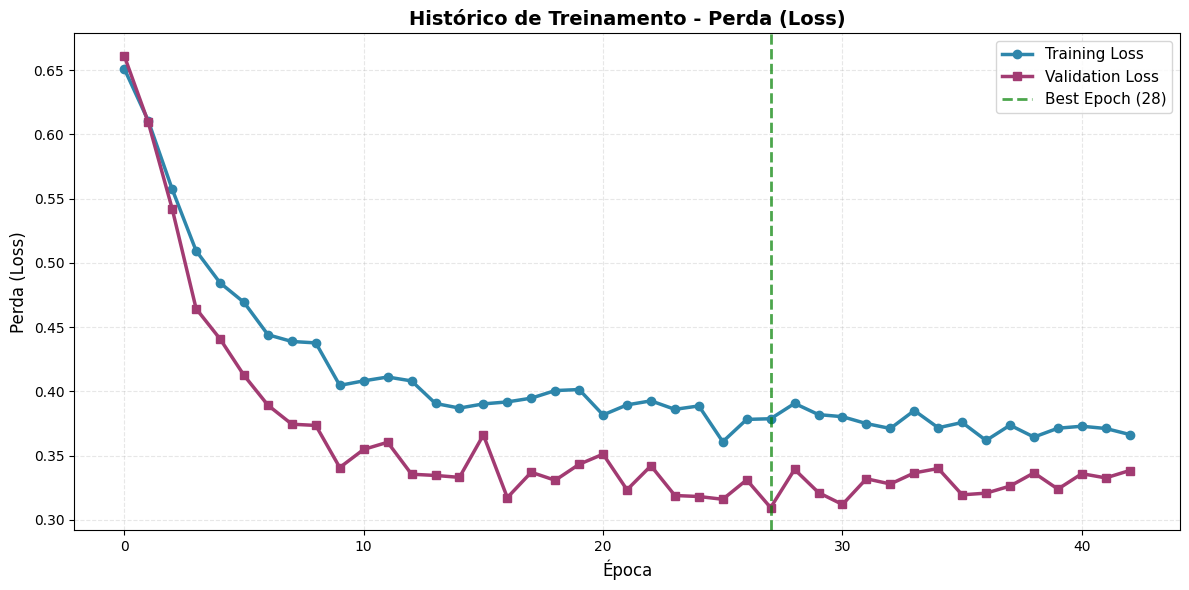


✓ TREINAMENTO CONCLUÍDO
  Melhor época: 28
  Melhor perda de validação: 0.309491
  Perda final de treino: 0.366411
  Redução de loss: 43.73%
  Dispositivo usado: Auto (Default TensorFlow)
  Early Stopping na época 43 (melhores pesos da época 28 restaurados)



In [42]:
# ========== Treinar o Modelo Siamesa ==========
history = train_siamese_network(
    model=siamese_network,
    loss_fn=binary_cross_loss,
    optimizer=opt,
    train_data=train_data,
    val_data=test_data,
    epochs=EPOCHS,
    checkpoint=checkpoint,
    checkpoint_prefix=checkpoint_prefix,
    checkpoint_interval=10
)

# **7  - Guardando o Modelo Criado**

In [62]:
MODELS_PATH = os.path.join(DATASET_PATH, 'models')

# Cria a pasta de modelos
os.makedirs(MODELS_PATH, exist_ok=True)

print(f"✓ Caminho de modelos: {MODELS_PATH}")

✓ Caminho de modelos: /content/models


In [63]:
model_path = os.path.join(MODELS_PATH, 'siamese_model_11.h5')
siamese_network.save(model_path)
print(f"✓ Modelo salvo em: {model_path}")

✓ Modelo salvo em: /content/models/siamese_model_11.h5


In [ ]:
# Recarrega o Modelo:
model_path = os.path.join(MODELS_PATH, 'siamese_model_10.h5')
model = tf.keras.models.load_model(model_path,
                                   custom_objects={'L1Distance':L1Distance, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})
print(f"✓ Modelo carregado de: {model_path}")

In [43]:
model = siamese_network


# **8 - Validação**

## 8.0 Dados de Validação

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rasty90/individual-dogs-dataset")

print("Path to dataset files:", path)

100%|██████████| 32.3M/32.3M [00:00<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rasty90/individual-dogs-dataset/versions/1


In [51]:
import random
import shutil

# Caminho onde o dataset foi baixado (entrar na subpasta dataset-dogs-individuals)
# Usar o 'path' retornado por kagglehub.dataset_download
dataset_path = Path(path) / "dataset-dogs-individuals"

# Listar todas as pastas de cachorros individuais
dog_folders = sorted([f for f in dataset_path.iterdir() if f.is_dir()])
print(f"Total de cachorros individuais no dataset Kaggle: {len(dog_folders)}")
for f in dog_folders:
    imgs = [i for i in f.iterdir() if i.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f"  - {f.name}: {len(imgs)} imagens")

# Caminhos de destino em application_data
input_image_path = os.path.join(DATASET_PATH, 'application_data', 'input_image')
verification_path = os.path.join(DATASET_PATH, 'application_data', 'verification_images')

os.makedirs(input_image_path, exist_ok=True)
os.makedirs(verification_path, exist_ok=True)

# Detectar cachorros já existentes para não sobrescrever
existing_input = [f for f in os.listdir(input_image_path) if f.startswith('input_image') and f.lower().endswith(('.jpg', '.jpeg', '.png'))]
existing_dogs = [f for f in os.listdir(verification_path) if os.path.isdir(os.path.join(verification_path, f)) and f.startswith('dog')]

# Encontrar o maior N existente
existing_nums = []
for name in existing_input:
    num = ''.join(filter(str.isdigit, name))
    if num:
        existing_nums.append(int(num))
for name in existing_dogs:
    num = ''.join(filter(str.isdigit, name))
    if num:
        existing_nums.append(int(num))

start_idx = max(existing_nums) + 1 if existing_nums else 1
print(f"\nCachorros já existentes: {len(set(existing_nums))} (dog1 a dog{max(existing_nums) if existing_nums else 0})")
print(f"Novos cachorros começarão a partir do dog{start_idx}\n")

# Para cada cachorro do Kaggle: selecionar 1 foto aleatória como input_imageN
# e copiar o restante para verification_images/dogN/
random.seed(SEED)

for idx, dog_folder in enumerate(dog_folders, start=start_idx):
    # Listar todas as imagens do cachorro
    all_images = sorted([
        img for img in dog_folder.iterdir()
        if img.suffix.lower() in ('.jpg', '.jpeg', '.png')
    ])

    if len(all_images) < 2:
        print(f"  ⚠️  {dog_folder.name} tem menos de 2 imagens, pulando...")
        continue

    # Selecionar 1 imagem aleatória como input_image
    input_img = random.choice(all_images)
    verification_imgs = [img for img in all_images if img != input_img]

    # Copiar input_image como input_imageN.jpg
    input_dest = os.path.join(input_image_path, f"input_image{idx}.jpg")
    shutil.copy2(str(input_img), input_dest)

    # Copiar o restante para verification_images/dogN/
    dog_dest = os.path.join(verification_path, f"dog{idx}")
    os.makedirs(dog_dest, exist_ok=True)

    for ver_img in verification_imgs:
        shutil.copy2(str(ver_img), os.path.join(dog_dest, ver_img.name))

    print(f"  ✓ Dog {idx} ({dog_folder.name}): input_image{idx}.jpg + {len(verification_imgs)} imagens de verificação")

total_dogs = idx
print(f"\n{'='*60}")
print(f"Dados de validação organizados com sucesso!")
print(f"  Cachorros existentes (preservados): dog1 a dog{start_idx - 1}")
print(f"  Cachorros do Kaggle (adicionados):  dog{start_idx} a dog{total_dogs}")
print(f"  Total de cachorros: {total_dogs}")
print(f"  Input images: {input_image_path}")
print(f"  Verification images: {verification_path}")
print(f"{'='*60}")

Total de cachorros individuais no dataset Kaggle: 15
  - alex: 24 imagens
  - ares: 17 imagens
  - bubu: 18 imagens
  - burger: 17 imagens
  - dataset-dogs-individuals: 0 imagens
  - demy: 15 imagens
  - gilda: 15 imagens
  - kali: 15 imagens
  - myrto: 18 imagens
  - perseus: 21 imagens
  - reggina: 15 imagens
  - ria: 15 imagens
  - roxy: 14 imagens
  - thor: 19 imagens
  - vita: 20 imagens

Cachorros já existentes: 0 (dog1 a dog0)
Novos cachorros começarão a partir do dog1

  ✓ Dog 1 (alex): input_image1.jpg + 23 imagens de verificação
  ✓ Dog 2 (ares): input_image2.jpg + 16 imagens de verificação
  ✓ Dog 3 (bubu): input_image3.jpg + 17 imagens de verificação
  ✓ Dog 4 (burger): input_image4.jpg + 16 imagens de verificação
  ⚠️  dataset-dogs-individuals tem menos de 2 imagens, pulando...
  ✓ Dog 6 (demy): input_image6.jpg + 14 imagens de verificação
  ✓ Dog 7 (gilda): input_image7.jpg + 14 imagens de verificação
  ✓ Dog 8 (kali): input_image8.jpg + 14 imagens de verificação
  ✓ Dog 

In [52]:
from PIL import Image

TARGET_SIZE = (105, 105)
SUPPORTED_FORMATS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

def resize_images_in_folder(folder_path):
    """Redimensiona todas as imagens de uma pasta para TARGET_SIZE usando PIL."""
    count = 0
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if not os.path.isfile(fpath) or not fname.lower().endswith(SUPPORTED_FORMATS):
            continue
        try:
            img = Image.open(fpath)
            if img.size != TARGET_SIZE:
                img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                img.save(fpath, quality=95)
                count += 1
        except Exception as e:
            print(f"  Erro em {fname}: {e}")
    return count

# Redimensionar imagens de input_image
input_img_path = os.path.join(DATASET_PATH, 'application_data', 'input_image')
n = resize_images_in_folder(input_img_path)
print(f"input_image: {n} imagens redimensionadas para {TARGET_SIZE}")

# Redimensionar imagens de cada pasta dogN em verification_images
verif_path = os.path.join(DATASET_PATH, 'application_data', 'verification_images')
for dog_folder in sorted(os.listdir(verif_path)):
    dog_path = os.path.join(verif_path, dog_folder)
    if os.path.isdir(dog_path):
        n = resize_images_in_folder(dog_path)
        print(f"{dog_folder}: {n} imagens redimensionadas para {TARGET_SIZE}")

input_image: 14 imagens redimensionadas para (105, 105)
dog1: 23 imagens redimensionadas para (105, 105)
dog10: 20 imagens redimensionadas para (105, 105)
dog11: 14 imagens redimensionadas para (105, 105)
dog12: 14 imagens redimensionadas para (105, 105)
dog13: 13 imagens redimensionadas para (105, 105)
dog14: 18 imagens redimensionadas para (105, 105)
dog15: 19 imagens redimensionadas para (105, 105)
dog2: 16 imagens redimensionadas para (105, 105)
dog3: 17 imagens redimensionadas para (105, 105)
dog4: 16 imagens redimensionadas para (105, 105)
dog6: 14 imagens redimensionadas para (105, 105)
dog7: 14 imagens redimensionadas para (105, 105)
dog8: 14 imagens redimensionadas para (105, 105)
dog9: 17 imagens redimensionadas para (105, 105)


## 8.1 Função de Verificação

In [48]:
def detectar_cachorro(model, detection_threshold=0.5, input_image_path=None, verification_path=None):
    """
    Verifica e classifica cachorros usando rede Siamesa.
    Compara cada input_imageN com todas as imagens de cada dogN.

    Args:
        model: Modelo Siamesa treinado
        detection_threshold (float): Threshold para correspondência positiva
        input_image_path (str): Caminho para pasta com imagens de entrada
        verification_path (str): Caminho para pasta com pastas de verificação

    Returns:
        dict: Resultados da classificação
    """

    if input_image_path is None:
        input_image_path = os.path.join(DATASET_PATH, 'application_data', 'input_image')
    if verification_path is None:
        verification_path = os.path.join(DATASET_PATH, 'application_data', 'verification_images')

    if not os.path.exists(input_image_path) or not os.path.exists(verification_path):
        print("⚠️  Caminhos não encontrados.")
        return None

    # Carregar imagens de entrada
    input_images = {}
    for img_file in sorted(os.listdir(input_image_path)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_num = ''.join(filter(str.isdigit, img_file))
            if img_num:
                img_path = os.path.join(input_image_path, img_file)
                input_images[img_num] = {
                    'filename': img_file,
                    'path': img_path,
                    'tensor': preprocess(img_path)
                }

    if not input_images:
        print("⚠️  Nenhuma imagem de entrada encontrada.")
        return None

    # Carregar todas as imagens de cada pasta de verificação
    verification_dogs = {}
    for dog_folder in sorted(os.listdir(verification_path)):
        dog_path = os.path.join(verification_path, dog_folder)
        if not os.path.isdir(dog_path):
            continue
        dog_num = ''.join(filter(str.isdigit, dog_folder))
        if dog_num:
            dog_images = []
            for img_file in sorted(os.listdir(dog_path)):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(dog_path, img_file)
                    dog_images.append({
                        'filename': img_file,
                        'path': img_path,
                        'tensor': preprocess(img_path)
                    })
            if dog_images:
                verification_dogs[dog_num] = {
                    'folder': dog_folder,
                    'images': dog_images
                }

    if not verification_dogs:
        print("⚠️  Nenhuma pasta de verificação encontrada.")
        return None

    # Contar total de comparações para o tqdm
    total_comparacoes = sum(
        len(verification_dogs[d]['images'])
        for _ in input_images
        for d in verification_dogs
    )

    total_ver_imgs = sum(len(v['images']) for v in verification_dogs.values())
    print(f"Inputs: {len(input_images)} | Dogs: {len(verification_dogs)} | Imagens de verificação: {total_ver_imgs}")
    print(f"Total de comparações: {total_comparacoes} | Threshold: {detection_threshold}\n")

    # Realizar comparações com barra de progresso
    resultados_detalhados = {}
    pbar = tqdm(total=total_comparacoes, desc="Comparando", unit="pred")

    for input_num in sorted(input_images.keys(), key=lambda x: int(x)):
        input_tensor = input_images[input_num]['tensor']
        resultados_input = {}

        for dog_num in sorted(verification_dogs.keys(), key=lambda x: int(x)):
            dog_images = verification_dogs[dog_num]['images']

            scores = []
            for dog_img in dog_images:
                prediction = model.predict(
                    [np.expand_dims(input_tensor, axis=0), np.expand_dims(dog_img['tensor'], axis=0)],
                    verbose=0
                )
                scores.append(float(prediction[0][0]))
                pbar.update(1)

            media = np.mean(scores)
            acertos_dog = sum(1 for s in scores if s > detection_threshold)

            resultados_input[dog_num] = {
                'media': media,
                'maximo': np.max(scores),
                'minimo': np.min(scores),
                'acertos': acertos_dog,
                'total_imagens': len(scores),
                'scores': scores
            }

        # Determinar melhor match
        melhor_dog = max(resultados_input.items(), key=lambda x: x[1]['media'])
        esperado_dog = input_num
        acertou = melhor_dog[0] == esperado_dog

        resultados_detalhados[input_num] = {
            'esperado': esperado_dog,
            'classificado_como': melhor_dog[0],
            'confianca': melhor_dog[1]['media'],
            'acertou': acertou,
            'detalhes_cachorros': resultados_input
        }

    pbar.close()

    # Exibir resultados
    print()
    for input_num in sorted(resultados_detalhados.keys(), key=lambda x: int(x)):
        r = resultados_detalhados[input_num]
        status = "✓" if r['acertou'] else "✗"
        print(f"  {status} Input {input_num} → Dog {r['classificado_como']} (score médio: {r['confianca']:.4f}) | Esperado: Dog {r['esperado']}")

    # Resumo
    acertos = sum(1 for r in resultados_detalhados.values() if r['acertou'])
    total = len(resultados_detalhados)
    accuracy = (acertos / total * 100) if total > 0 else 0

    print(f"\nResultado: {acertos}/{total} acertos ({accuracy:.1f}%)")

    return {
        'acertos': acertos,
        'erros': total - acertos,
        'total': total,
        'accuracy': accuracy,
        'detalhes': resultados_detalhados
    }

In [53]:
# Listar imagens de teste localmente
app_data_path = os.path.join(DATASET_PATH, 'application_data', 'input_image')
if os.path.exists(app_data_path):
    print(f"\nArquivos em {app_data_path}:")
    for f in os.listdir(app_data_path):
        print(f"  - {f}")
else:
    print(f"⚠️  Diretório não encontrado: {app_data_path}")


Arquivos em /content/application_data/input_image:
  - input_image7.jpg
  - input_image8.jpg
  - input_image14.jpg
  - input_image15.jpg
  - input_image4.jpg
  - input_image2.jpg
  - input_image13.jpg
  - input_image10.jpg
  - input_image9.jpg
  - input_image12.jpg
  - input_image3.jpg
  - input_image11.jpg
  - input_image1.jpg
  - input_image6.jpg


In [54]:
# Executar detecção de cachorros
resultados = detectar_cachorro(
    model=model,
    detection_threshold=0.5,
    input_image_path=os.path.join(DATASET_PATH, 'application_data', 'input_image'),
    verification_path=os.path.join(DATASET_PATH, 'application_data', 'verification_images')
)

Inputs: 14 | Dogs: 14 | Imagens de verificação: 229
Total de comparações: 3206 | Threshold: 0.5



Comparando:   0%|          | 0/3206 [00:00<?, ?pred/s]


  ✗ Input 1 → Dog 2 (score médio: 0.2886) | Esperado: Dog 1
  ✗ Input 2 → Dog 12 (score médio: 0.2811) | Esperado: Dog 2
  ✗ Input 3 → Dog 9 (score médio: 0.2455) | Esperado: Dog 3
  ✗ Input 4 → Dog 11 (score médio: 0.2410) | Esperado: Dog 4
  ✗ Input 6 → Dog 11 (score médio: 0.3029) | Esperado: Dog 6
  ✗ Input 7 → Dog 12 (score médio: 0.2062) | Esperado: Dog 7
  ✗ Input 8 → Dog 9 (score médio: 0.2264) | Esperado: Dog 8
  ✗ Input 9 → Dog 11 (score médio: 0.2681) | Esperado: Dog 9
  ✗ Input 10 → Dog 7 (score médio: 0.2067) | Esperado: Dog 10
  ✗ Input 11 → Dog 9 (score médio: 0.3351) | Esperado: Dog 11
  ✗ Input 12 → Dog 2 (score médio: 0.3175) | Esperado: Dog 12
  ✗ Input 13 → Dog 15 (score médio: 0.1909) | Esperado: Dog 13
  ✗ Input 14 → Dog 12 (score médio: 0.2790) | Esperado: Dog 14
  ✗ Input 15 → Dog 9 (score médio: 0.3081) | Esperado: Dog 15

Resultado: 0/14 acertos (0.0%)


## 8.2 - Matriz Confusão

In [55]:
def matriz_confusao_detalhada(resultados, detection_threshold=0.5):
    """
    Gera matriz de confusão detalhada com heatmaps por par (dogX vs input_imageY).

    Para cada par (dogX, input_imageY):
      - Ground truth: dogN com input_imageN = mesmo cachorro, senão = diferentes
      - Classificação: score > threshold = "mesmo cachorro"

    Args:
        resultados: Dicionário retornado por detectar_cachorro()
        detection_threshold: Threshold para classificação positiva

    Returns:
        dict com DataFrames de corretas, incorretas e scores médios
    """
    if not resultados or resultados['total'] <= 0:
        print("Sem resultados para analisar.")
        return None

    print(f"\n{'='*70}")
    print("MATRIZ DE CONFUSÃO DETALHADA")
    print(f"Threshold de detecção: {detection_threshold}")
    print(f"{'='*70}\n")

    img_nums = sorted(resultados['detalhes'].keys(), key=lambda x: int(x))
    dog_nums = sorted(
        resultados['detalhes'][img_nums[0]]['detalhes_cachorros'].keys(),
        key=lambda x: int(x)
    )

    mat_positivas = []
    mat_total = []
    mat_corretas = []
    mat_incorretas = []
    mat_scores_media = []

    for dog_num in dog_nums:
        row_pos = []
        row_total = []
        row_corretas = []
        row_incorretas = []
        row_media = []

        for img_num in img_nums:
            detalhe = resultados['detalhes'][img_num]
            dog_stats = detalhe['detalhes_cachorros'][dog_num]

            # Recalcular positivas com o threshold fornecido
            scores = dog_stats['scores']
            positivas = sum(1 for s in scores if s > detection_threshold)
            total = len(scores)
            negativas = total - positivas
            media = dog_stats['media']

            mesmo_cachorro = (dog_num == img_num)

            if mesmo_cachorro:
                corretas = positivas
                incorretas = negativas
            else:
                corretas = negativas
                incorretas = positivas

            row_pos.append(positivas)
            row_total.append(total)
            row_corretas.append(corretas)
            row_incorretas.append(incorretas)
            row_media.append(media)

        mat_positivas.append(row_pos)
        mat_total.append(row_total)
        mat_corretas.append(row_corretas)
        mat_incorretas.append(row_incorretas)
        mat_scores_media.append(row_media)

    idx_labels = [f"Dog {n}" for n in dog_nums]
    col_labels = [f"input_image{n}" for n in img_nums]

    df_corretas = pd.DataFrame(mat_corretas, index=idx_labels, columns=col_labels)
    df_incorretas = pd.DataFrame(mat_incorretas, index=idx_labels, columns=col_labels)
    df_media = pd.DataFrame(mat_scores_media, index=idx_labels, columns=col_labels)

    # ========== TABELA TEXTUAL ==========
    print("Classificações por par (dogX vs input_imageY):\n")
    print(f"{'Par':<28} {'Ground Truth':<18} {'Positivas':<12} {'Corretas':<12} {'Incorretas':<12} {'Score Médio':<12}")
    print("-" * 94)

    total_corretas_global = 0
    total_incorretas_global = 0

    for i, dog_num in enumerate(dog_nums):
        for j, img_num in enumerate(img_nums):
            mesmo = "Mesmo cachorro" if dog_num == img_num else "Diferentes"
            pos = mat_positivas[i][j]
            tot = mat_total[i][j]
            cor = mat_corretas[i][j]
            inc = mat_incorretas[i][j]
            med = mat_scores_media[i][j]

            total_corretas_global += cor
            total_incorretas_global += inc

            par = f"Dog {dog_num} vs input_image{img_num}"
            print(f"{par:<28} {mesmo:<18} {pos}/{tot:<10} {cor}/{tot:<10} {inc}/{tot:<10} {med:<.4f}")

    print("-" * 94)
    total_geral = total_corretas_global + total_incorretas_global
    acc = total_corretas_global / total_geral * 100 if total_geral > 0 else 0
    print(f"{'TOTAL':<28} {'':<18} {'':<12} {total_corretas_global}/{total_geral:<10} {total_incorretas_global}/{total_geral:<10} Acc: {acc:.2f}%")

    # ========== 3 HEATMAPS ==========
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    sns.heatmap(df_media, annot=True, fmt='.4f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=1, linecolor='white',
                cbar_kws={'label': 'Score Médio'}, ax=axes[0])
    axes[0].set_title('Score Médio\n(dogX vs input_imageY)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Pasta de Verificação (Dog)', fontsize=10)
    axes[0].set_xlabel('Imagem de Entrada', fontsize=10)

    sns.heatmap(df_corretas, annot=True, fmt='d', cmap='Greens',
                linewidths=1, linecolor='white',
                cbar_kws={'label': 'Qtd Corretas'}, ax=axes[1])
    axes[1].set_title('Classificações Corretas\n(por par dogX vs input_imageY)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Pasta de Verificação (Dog)', fontsize=10)
    axes[1].set_xlabel('Imagem de Entrada', fontsize=10)

    sns.heatmap(df_incorretas, annot=True, fmt='d', cmap='Reds',
                linewidths=1, linecolor='white',
                cbar_kws={'label': 'Qtd Incorretas'}, ax=axes[2])
    axes[2].set_title('Classificações Incorretas\n(por par dogX vs input_imageY)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Pasta de Verificação (Dog)', fontsize=10)
    axes[2].set_xlabel('Imagem de Entrada', fontsize=10)

    for a in axes:
        for i in range(min(len(dog_nums), len(img_nums))):
            a.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='blue', linewidth=3))

    plt.tight_layout()
    plt.show()

    return {
        'df_corretas': df_corretas, 'df_incorretas': df_incorretas, 'df_media': df_media,
        'threshold': detection_threshold
    }

In [56]:
def metricas_globais(resultados, detection_threshold=0.5):
    """
    Calcula e exibe métricas globais (TP, FP, FN, TN, precision, recall, f1, accuracy)
    e plota a matriz de confusão binária 2x2.

    Args:
        resultados: Dicionário retornado por detectar_cachorro()
        detection_threshold: Threshold para classificação positiva

    Returns:
        dict com TP, FN, FP, TN, precision, recall, f1, accuracy
    """
    if not resultados or resultados['total'] <= 0:
        print("Sem resultados para analisar.")
        return None

    img_nums = sorted(resultados['detalhes'].keys(), key=lambda x: int(x))
    dog_nums = sorted(
        resultados['detalhes'][img_nums[0]]['detalhes_cachorros'].keys(),
        key=lambda x: int(x)
    )

    # ========== MÉTRICAS TP/FP/FN/TN ==========
    TP = 0; FN = 0; FP = 0; TN = 0

    for dog_num in dog_nums:
        for img_num in img_nums:
            dog_stats = resultados['detalhes'][img_num]['detalhes_cachorros'][dog_num]
            scores = dog_stats['scores']
            pos = sum(1 for s in scores if s > detection_threshold)
            tot = len(scores)
            neg = tot - pos
            if dog_num == img_num:
                TP += pos; FN += neg
            else:
                FP += pos; TN += neg

    total_all = TP + FN + FP + TN
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy_global = (TP + TN) / total_all * 100 if total_all > 0 else 0

    print(f"\n{'='*70}")
    print("MÉTRICAS GLOBAIS (todas as comparações imagem-a-imagem)")
    print(f"{'='*70}")
    print(f"  TP (mesmo cachorro, classificado como mesmo):     {TP}")
    print(f"  FN (mesmo cachorro, classificado como diferente): {FN}")
    print(f"  FP (diferente, classificado como mesmo):          {FP}")
    print(f"  TN (diferente, classificado como diferente):      {TN}")
    print(f"  Total de comparações: {total_all}")
    print(f"\n  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Accuracy:  {accuracy_global:.2f}%")

    # ========== MATRIZ BINÁRIA 2x2 ==========
    conf_2x2 = np.array([[TP, FN], [FP, TN]])
    df_conf2 = pd.DataFrame(conf_2x2,
                            index=['Real: Mesmo', 'Real: Diferente'],
                            columns=['Pred: Mesmo', 'Pred: Diferente'])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(df_conf2, annot=True, fmt='d', cmap='Blues',
                linewidths=1, linecolor='white',
                cbar_kws={'label': 'Contagem'}, ax=ax)
    ax.set_title('Matriz de Confusão Binária\n(Mesmo Cachorro vs Diferente)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Classe Real', fontsize=11)
    ax.set_xlabel('Classe Predita', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {
        'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN,
        'precision': precision, 'recall': recall, 'f1': f1,
        'accuracy': accuracy_global, 'threshold': detection_threshold
    }


MATRIZ DE CONFUSÃO DETALHADA
Threshold de detecção: 0.5

Classificações por par (dogX vs input_imageY):

Par                          Ground Truth       Positivas    Corretas     Incorretas   Score Médio 
----------------------------------------------------------------------------------------------
Dog 1 vs input_image1        Mesmo cachorro     0/23         0/23         23/23         0.2526
Dog 1 vs input_image2        Diferentes         0/23         23/23         0/23         0.2298
Dog 1 vs input_image3        Diferentes         0/23         23/23         0/23         0.1018
Dog 1 vs input_image4        Diferentes         0/23         23/23         0/23         0.1395
Dog 1 vs input_image6        Diferentes         0/23         23/23         0/23         0.1878
Dog 1 vs input_image7        Diferentes         0/23         23/23         0/23         0.1297
Dog 1 vs input_image8        Diferentes         0/23         23/23         0/23         0.0903
Dog 1 vs input_image9        Difer

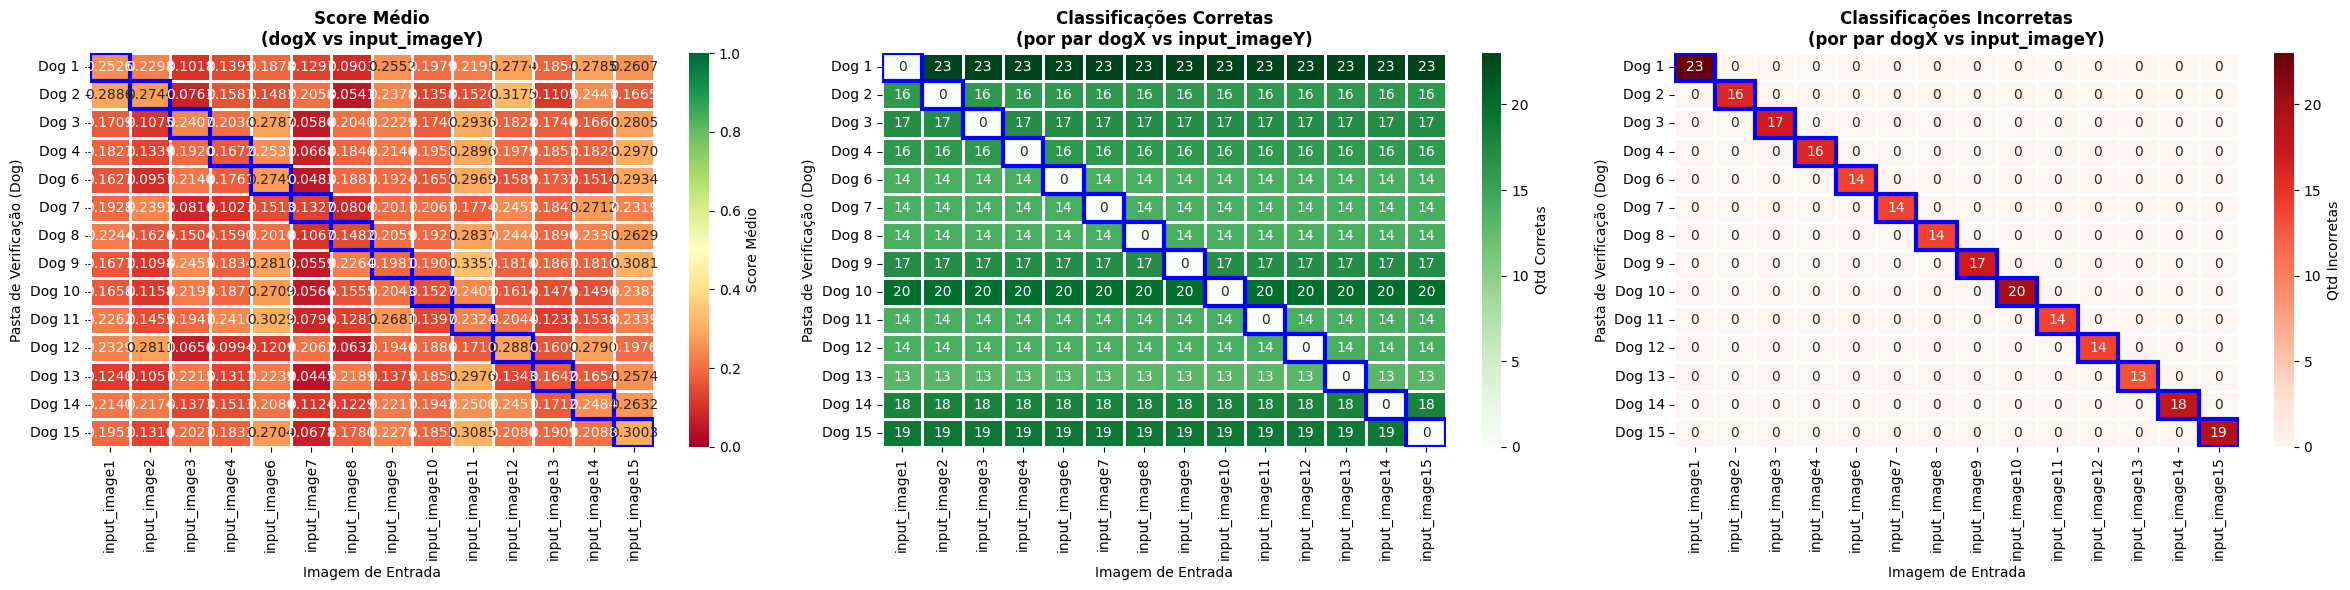

In [57]:
# Executar matriz de confusão detalhada (altere o threshold para testar diferentes valores)
detalhes = matriz_confusao_detalhada(resultados, detection_threshold=0.5)


MÉTRICAS GLOBAIS (todas as comparações imagem-a-imagem)
  TP (mesmo cachorro, classificado como mesmo):     0
  FN (mesmo cachorro, classificado como diferente): 229
  FP (diferente, classificado como mesmo):          0
  TN (diferente, classificado como diferente):      2977
  Total de comparações: 3206

  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Accuracy:  92.86%


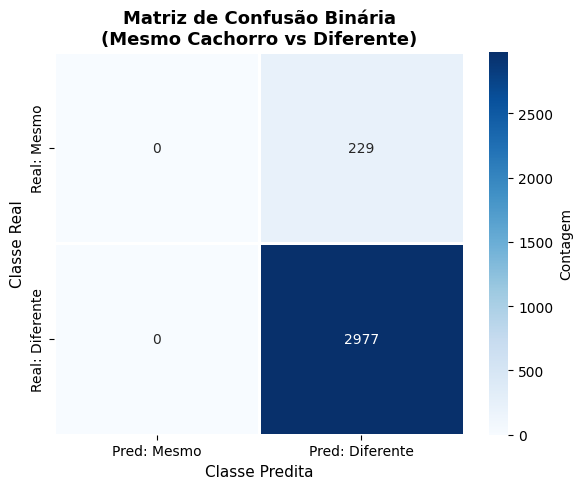

In [58]:
metricas = metricas_globais(resultados, detection_threshold=0.5)

## 8.3 Curva ROC (AUC)

In [59]:
def curva_roc(resultados, detection_threshold=0.5):
    """
    Gera a curva ROC a partir dos scores individuais de cada comparação.

    Args:
        resultados: Dicionário retornado por detectar_cachorro()
        detection_threshold: Threshold atual para marcar no gráfico

    Returns:
        dict com fpr, tpr, thresholds, auc, threshold_optimo
    """
    if not resultados or resultados['total'] <= 0:
        print("Sem resultados para analisar.")
        return None

    img_nums = sorted(resultados['detalhes'].keys(), key=lambda x: int(x))
    dog_nums = sorted(
        resultados['detalhes'][img_nums[0]]['detalhes_cachorros'].keys(),
        key=lambda x: int(x)
    )

    y_true_roc = []
    y_scores_roc = []

    for img_num in img_nums:
        detalhe = resultados['detalhes'][img_num]
        for dog_num in dog_nums:
            dog_stats = detalhe['detalhes_cachorros'][dog_num]
            label = 1 if dog_num == img_num else 0
            for s in dog_stats['scores']:
                y_true_roc.append(label)
                y_scores_roc.append(s)

    y_true_roc = np.array(y_true_roc)
    y_scores_roc = np.array(y_scores_roc)

    fpr, tpr, thresholds = roc_curve(y_true_roc, y_scores_roc)
    roc_auc = auc(fpr, tpr)

    idx_thresh = np.argmin(np.abs(thresholds - detection_threshold))
    youden = tpr - fpr
    idx_optimo = np.argmax(youden)
    threshold_optimo = thresholds[idx_optimo]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Aleatório (AUC = 0.5)')
    ax.plot(fpr[idx_thresh], tpr[idx_thresh], 'bo', markersize=10,
            label=f'Threshold atual = {detection_threshold:.2f}\n  (FPR={fpr[idx_thresh]:.3f}, TPR={tpr[idx_thresh]:.3f})')
    ax.plot(fpr[idx_optimo], tpr[idx_optimo], 'r*', markersize=15,
            label=f'Threshold ótimo = {threshold_optimo:.4f}\n  (FPR={fpr[idx_optimo]:.3f}, TPR={tpr[idx_optimo]:.3f})')

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
    ax.set_title('Curva ROC - Rede Siamesa\n(Mesmo Cachorro vs Diferente)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTotal de comparações individuais: {len(y_true_roc)}")
    print(f"  Positivas (mesmo cachorro): {int(y_true_roc.sum())}")
    print(f"  Negativas (diferente):      {int(len(y_true_roc) - y_true_roc.sum())}")
    print(f"\nAUC (Area Under Curve): {roc_auc:.4f}")
    print(f"Threshold atual:  {detection_threshold:.2f} → TPR={tpr[idx_thresh]:.4f}, FPR={fpr[idx_thresh]:.4f}")
    print(f"Threshold ótimo:  {threshold_optimo:.4f} → TPR={tpr[idx_optimo]:.4f}, FPR={fpr[idx_optimo]:.4f}")

    return {
        'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds,
        'auc': roc_auc, 'threshold_optimo': threshold_optimo
    }

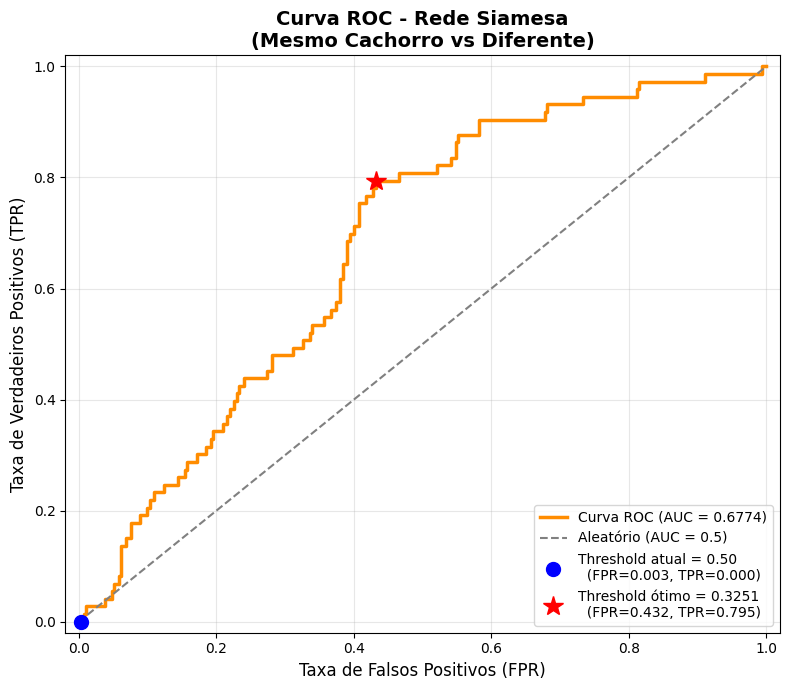


Total de comparações individuais: 365
  Positivas (mesmo cachorro): 73
  Negativas (diferente):      292

AUC (Area Under Curve): 0.6774
Threshold atual:  0.50 → TPR=0.0000, FPR=0.0034
Threshold ótimo:  0.3251 → TPR=0.7945, FPR=0.4315


In [ ]:
# Executar curva ROC (altere o threshold para marcar um ponto diferente no gráfico)
roc_resultado = curva_roc(resultados, detection_threshold=0.5)

## 8.3 Teste do novo Threashold


MATRIZ DE CONFUSÃO DETALHADA
Threshold de detecção: 0.3251

Classificações por par (dogX vs input_imageY):

Par                          Ground Truth       Positivas    Corretas     Incorretas   Score Médio 
----------------------------------------------------------------------------------------------
Dog 1 vs input_image1        Mesmo cachorro     4/23         4/23         19/23         0.2526
Dog 1 vs input_image2        Diferentes         4/23         19/23         4/23         0.2298
Dog 1 vs input_image3        Diferentes         0/23         23/23         0/23         0.1018
Dog 1 vs input_image4        Diferentes         0/23         23/23         0/23         0.1395
Dog 1 vs input_image6        Diferentes         0/23         23/23         0/23         0.1878
Dog 1 vs input_image7        Diferentes         0/23         23/23         0/23         0.1297
Dog 1 vs input_image8        Diferentes         0/23         23/23         0/23         0.0903
Dog 1 vs input_image9        Di

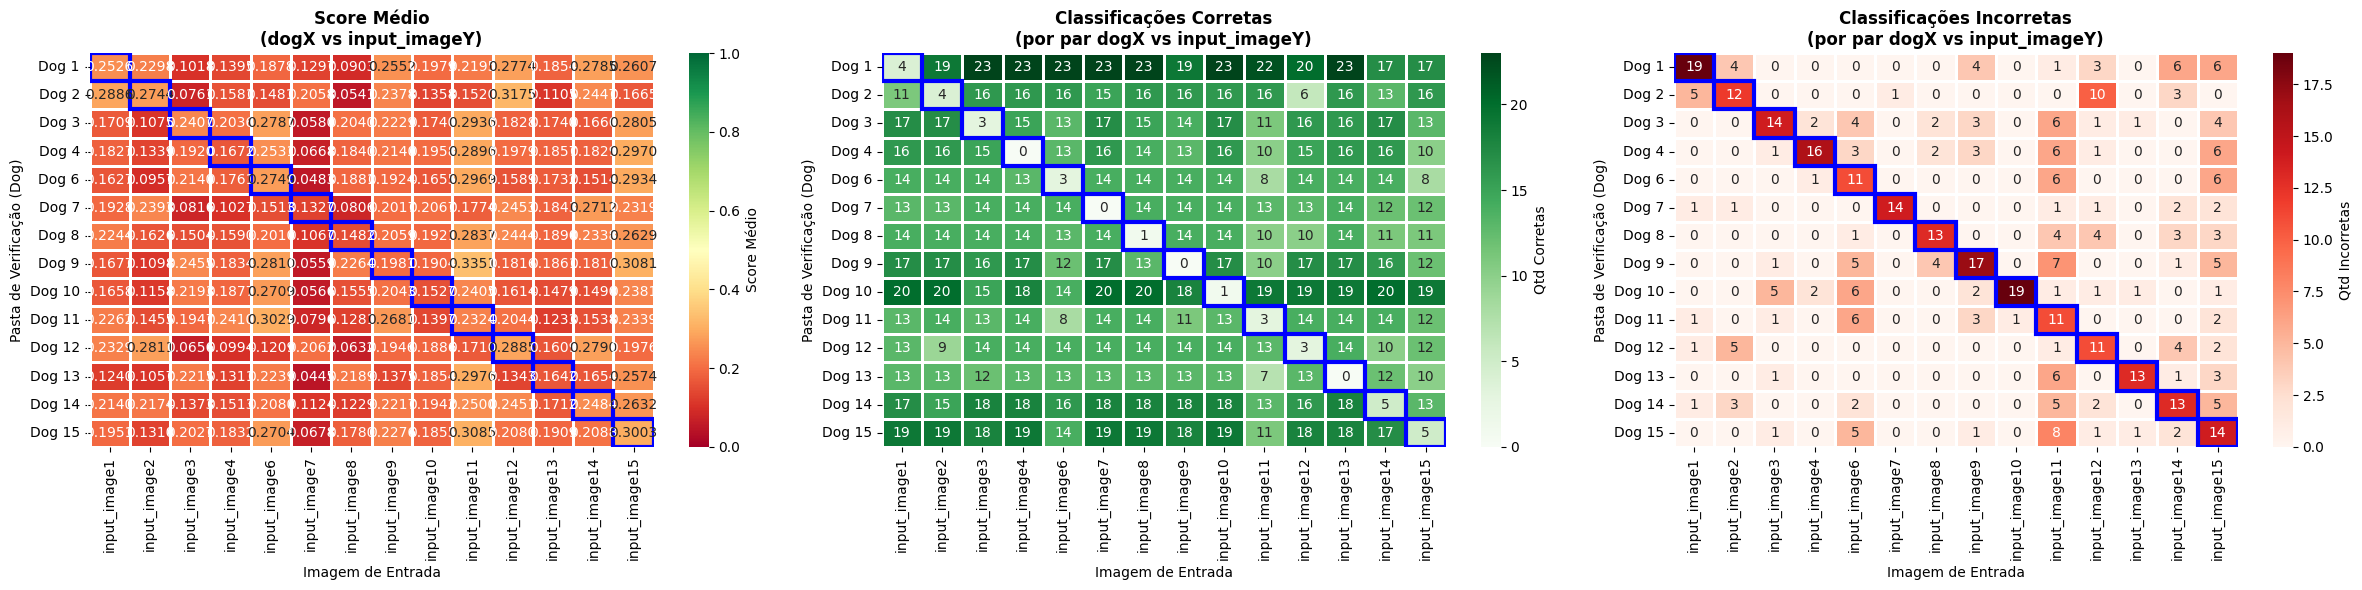


MÉTRICAS GLOBAIS (todas as comparações imagem-a-imagem)
  TP (mesmo cachorro, classificado como mesmo):     32
  FN (mesmo cachorro, classificado como diferente): 197
  FP (diferente, classificado como mesmo):          241
  TN (diferente, classificado como diferente):      2736
  Total de comparações: 3206

  Precision: 0.1172
  Recall:    0.1397
  F1-Score:  0.1275
  Accuracy:  86.34%


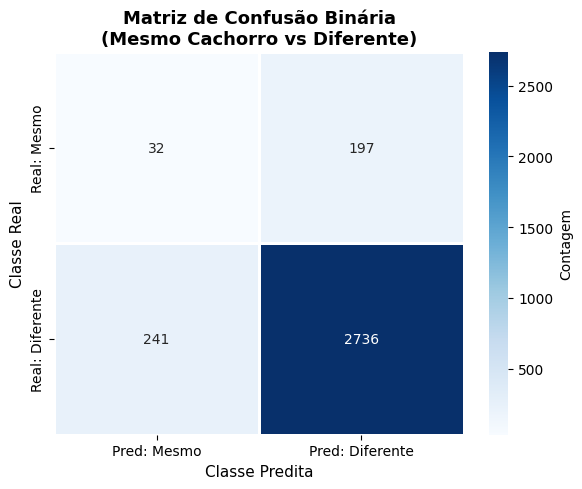

In [60]:
detalhes = matriz_confusao_detalhada(resultados, detection_threshold=0.3251)
metricas = metricas_globais(resultados, detection_threshold=0.3251)

De acordo com os resultados obtidos, provavelmente é necessária mais imagens de treinamento, tendo em mente que foram utilizados apens 50 imagens âncoras para treinamento. Talvez uma implementação RPA utilizando a página do Flickr seria eficiente na aquisição de imagens de cachorros específicos. Devido ao tempo limitado de produção de todo o projeto de TCC, a aquisição de imagens de cachorros foi limitada.

# **9 - Convertendo para tensorflow Lite**

In [ ]:
# Converter para o formato TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

model_path = os.path.join(MODELS_PATH, 'siamese_model_lite_2.tflite')
with open(model_path, 'wb') as f:
    f.write(tflite_model)

In [ ]:
print(MODELS_PATH)
type(siamese_network)

In [ ]:
!xxd -i "/content/drive/My Drive/TCC_rakel+Artur/Dataset/models/siamese_model_lite_2.tflite" > model2.h